<a href="https://colab.research.google.com/github/LuGorr/NLP-Assignments/blob/main/A1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group members

|  Name   |  Surname   |     Email                            |    Student ID                                             |
| :-----: | :--------: | :----------------------------------: | :-----------------------------------------------------: |
| Ludovico  | Gorrieri   | `ludovico.gorrieri@studio.unibo.it`   |  0001199160 |
| Alessandro  | Capialbi | `alessandro.capialbi@studio.unibo.it`  | 0001191564 |
| Faezeh  | Sarlakifar | `faezeh.sarlakifar@studio.unibo.it`  | 0001164608 |
| Giacomo  | Antonelli | `giacomo.antonelli4@studio.unibo.it`  | TODO |

## Project setup.

### Clone the repository and install the required dependencies.

In [ ]:
# @title
!git clone https://github.com/nlp-unibo/nlp-course-material.git
%cd "nlp-course-material/2025-2026/Assignment 1"
!pip install -qq gensim
print("\ngensim installed!")
!pip install -qq plotly
print("plotly installed!")
!pip install -qq nltk
print("nltk installed!")
!pip install -qq transformers
print("transformers installed!")
!pip install -qq datasets
print("datasets installed!")
!pip install -qq accelerate -U
print("accelerate installed!")
!pip install -qq evaluate
print("evaluate installed!")
!pip install -qq bitsandbytes
print("bitsandbytes installed!")
!pip install -qq wandb
print("wandb installed!")
!pip install -qq optuna
print("optuna installed!")

fatal: destination path 'nlp-course-material' already exists and is not an empty directory.
/tf/notebooks/Uni/magistrale/NLP/NLP-Assignments/A1/nlp-course-material/2025-2026/Assignment 1

gensim installed!
plotly installed!
nltk installed!
transformers installed!
datasets installed!
accelerate installed!
evaluate installed!
bitsandbytes installed!
wandb installed!
optuna installed!


### Import the reqired libraries.

In [ ]:
# System and Utils.
import os
import sys
import re
import json
import gc
import random
import ctypes
import psutil
import statistics
from random import shuffle
from collections import Counter
from itertools import product
import IPython

# Pandas and Numpy.
import numpy as np
import pandas as pd

# NLTK and Gensim.
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import (word_tokenize,
                            sent_tokenize,
                            WhitespaceTokenizer)
import gensim
import gensim.downloader as gloader
from gensim.models import KeyedVectors

# Visualization.
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Scikit-Learn, WAndB and Optuna.
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import wandb
import optuna
from optuna.trial import TrialState

# TensorFlow and Keras.
import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, Callback
from tqdm.keras import TqdmCallback
os.environ["KERAS_BACKEND"] = "tensorflow"
tf.config.run_functions_eagerly(True)

# PyTorch and HuggingFace.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup,
                          Trainer,
                          TrainingArguments,
                          EarlyStoppingCallback,
                          DataCollatorWithPadding,
                          set_seed)
import evaluate

# Define the device: use CUDA (GPU) if available, anderswise default to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-03 11:06:01.493501: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Task 1 & 2

### NTLK and function definitions.

In [ ]:
# Prepare NLTK Resources.
resources = [
    ('corpora/omw-1.4', 'omw-1.4'),
    ('corpora/wordnet', 'wordnet'),
    ('taggers/averaged_perceptron_tagger', 'averaged_perceptron_tagger'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('tokenizers/punkt', 'punkt')
]

for resource_path, download_name in resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

# Initialize the tokenizer and lemmatizer.
tokenizer = WhitespaceTokenizer()
lemmatizer = WordNetLemmatizer()

def get_wordnet_key(pos_tag):
    """
    Maps Penn Treebank POS tags to WordNet's format
    (Required by WordNetLemmatizer).
    """
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

def lem_text(row):
    """
    Tokenizes and lemmatizes a row's tweet.
    """
    tokens = tokenizer.tokenize(row.tweet) # Tokenize.
    tagged = pos_tag(tokens) # Tag the tokens.

    # Convert the tagged tokens to WordNet and lemmatize them.
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

def cleaner(row):
    """
    Cleans a row's tweet.
    """
    text = row.tweet
    text = text.lower() # Transform to lowercase.
    text = re.sub(r'https?:\/\/.\S+', '', text) # Remove URLs.
    text = re.sub(r'[@#].\S+', '', text) # Remove hashtags and mentions.

    text = re.sub( # Remove unwanted symbols.
        "["
            u"\U0001F600-\U0001F64F"  # Emoticons.
            u"\U0001F300-\U0001F5FF"  # Symbols & pictographs.
            u"\U0001F680-\U0001F6FF"  # Transport & map symbols.
            u"\U0001F1E0-\U0001F1FF"  # Flags.
                                    "]+", '', text
    )
    # Only keep numbers and latin alphabet letters.
    text = re.sub(r'[^a-z^0-9^\s]*', '', text)

    text = ' '.join(text.split())
    return text

def plot_dists(train, test, extra_title=""):
    """
    Plots train and test set distributions.
    - Class distribution (in percentage points over the set).
    - Tweet length distribution.
    - Per class tweet length distribution.
    """
    # Class distribution histogram.
    pio.renderers.default = "colab"
    label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}
    category_order = ["NOT SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]
    train_plot = train.copy()
    test_plot = test.copy()
    train_plot["dataset"] = "Training Set"
    test_plot["dataset"] = "Test Set"
    df_all = pd.concat([train_plot, test_plot])
    df_all["label_name"] = df_all["label"].map(label_map)
    df_counts = df_all.groupby(['dataset', 'label_name']).size().reset_index(name='counts')
    df_counts['percent'] = df_counts.groupby('dataset')['counts'].transform(lambda x: (x / x.sum()) * 100)
    fig = px.bar(
        df_counts,
        x="label_name",
        y="percent",
        color="label_name",
        facet_col_spacing=0.05,
        facet_col="dataset",
        category_orders={"label_name": category_order, "dataset": ["Training Set", "Test Set"]},
        color_discrete_sequence=px.colors.sequential.Plasma,
        text=df_counts['percent'].apply(lambda x: f'{x:.1f}%'), # Etichette precise
        labels={"label_name": "Class", "percent": "Percentage (%)"}
    )
    fig.update_layout(
        width=1000, height=500,
        showlegend=False,
        bargap=0.2,
        title_text="Class Distribution: Percentage of each Set " + extra_title,
        title_x=0.5
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    fig.update_traces(textposition='outside') # Mette i numeri sopra le barre
    fig.update_yaxes(title_text="Percentage (%)", ticksuffix="%")
    fig.show()

    # Tweet length distribution histogram + kernel density estimator.
    train_plot["text_length"] = train_plot["text"].apply(lambda x: len(x.split()))
    plt.figure(figsize=(10,5))
    sns.histplot(train_plot["text_length"], bins=30, kde=True, color="purple")
    plt.title("Distribution of Tweet Lengths (Training Set)")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

    # Per class tweet length distribution boxplot.
    plt.figure(figsize=(8,5))
    sns.boxplot(x="label", y="text_length",hue="label", legend=False, data=train_plot, palette="viridis")
    plt.title("Tweet Length by Class")
    plt.xlabel("Class")
    plt.ylabel("Tweet Length (words)")
    plt.xticks([0,1,2,3], ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'])
    plt.show()

# Aggregates the labels (labels_task2).


def aggregator(row):

    mapping = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
    }

    votes = [vote for vote in row.labels_task2 if vote != "UNKNOWN"]
    counts = Counter(votes)

    if not counts:
        return None

    top_two = counts.most_common(2)

    # 1. If everyone agreed or there's only one type of label
    if len(top_two) == 1:
        return mapping[top_two[0][0]]

    # 2. Check for a clear majority (Top vote > Second place vote)
    if top_two[0][1] > top_two[1][1]:
        return mapping[top_two[0][0]]

    # 3. If there is a tie (e.g., 3 vs 3), return None to filter out later
    return None

def random_upsampler(ds):
    label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}

    # Count the labels.
    label_counts = [ds.label[ds.label == i].count() for i in label_map.keys()]

    majority = np.argmax(label_counts) # Get the majority class.

    # Perform random upsampling until all the classes have an equal amount of entries.
    for i in label_map:
        if i != majority:
            for _ in range(label_counts[majority] - label_counts[i]):
                ds = pd.concat([pd.DataFrame(ds[ds.label == i].sample(1), \
                                columns=ds.columns), ds], ignore_index=True)

    ds = ds.reset_index(drop=True)
    print("AUGMENTATION DONE!")
    return ds



### Clean, split and lemmatize the dataset.

train_LSTM
test_LSTM
val_LSTM
train_ROBERTA
test_ROBERTA
val_ROBERTA
                                                       text  label
id_EXIST                                                          
200001    ffs how about lay the blame on the bastard who...      0
200002    write a uni essay in my local pub with a coffe...      3
200003    it be 2021 not 1921 i dont appreciate that on ...      3
200004    this be unacceptable use her title a you do fo...      0
200005    make yourself a hard target basically boil dow...      0
...                                                     ...    ...
203254    maam if i say that you look like a whorewould ...      1
203256    idk why yall bitch think have half your as han...      1
203257    this have be a part of an experiment with what...      2
203258    take me already not yet you gotta be readyim d...      1
203259                      why do you look like a whore lh      1

[2873 rows x 2 columns]


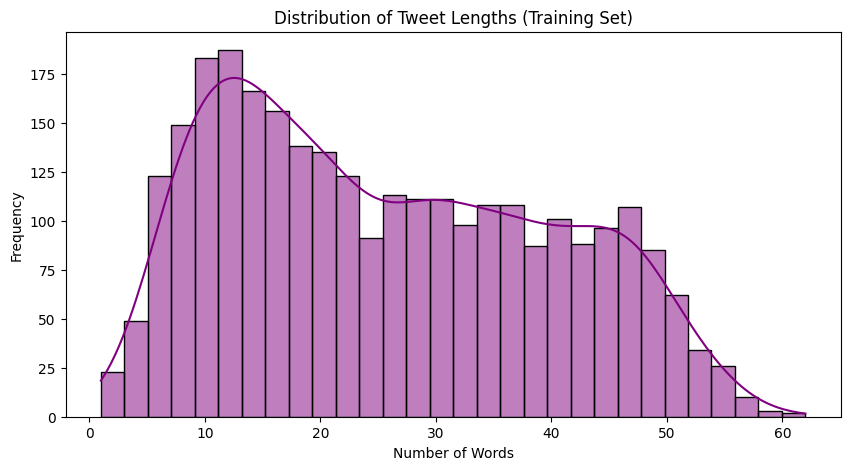

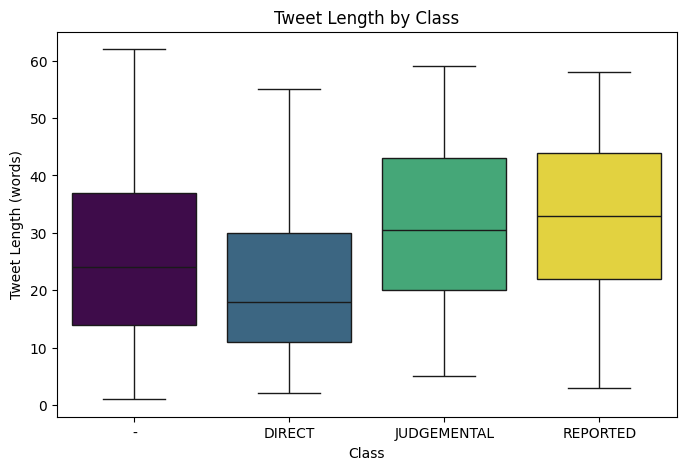

In [ ]:
# Load the JSON files.
with open("data/training.json", "r") as tr, \
     open("data/validation.json", "r") as te, \
     open("data/test.json", "r") as va:
    train_json = json.load(tr)
    val_json = json.load(te)
    test_json = json.load(va)

# Create the dataframes (setting the index to id_EXIST).
dts = {
    "train_LSTM": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test_LSTM": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val_LSTM": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST"),
    "train_ROBERTA": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test_ROBERTA": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val_ROBERTA": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST")
}

# Unnecessary columns
drop_cols = ["number_annotators", "annotators", "gender_annotators",
    "age_annotators", "labels_task1", "labels_task3", "split", "lang"]

is_roberta = re.compile(r"_ROBERTA")

# Clean and lemmatize the data
for name, df in dts.items():
    print(name)
    df = df[df.lang == "en"].copy() # Drop spanish.

    df = df.drop(columns=drop_cols) # Drop unnecessary cols.

    df["labels"] = df.apply(aggregator, axis=1) # Aggregate the labels (maj. voting).
    # Remove rows where aggregator returned None (no clear majority)
    df = df.dropna(subset=['labels'])

    # Convert to integer
    df['labels'] = df['labels'].astype(int)

    df = df.drop(columns="labels_task2") # Drop the old label column.
    if(is_roberta.search(name) is None):
        for func in [cleaner, lem_text]:
            df["tweet"] = df.apply(func, axis=1) # Clean the tweets.

    # Rename the columns
    df.rename(columns={"tweet": "text", "labels": "label"}, inplace=True)

    dts[name] = df

# Get the clean train, test and validation datasets
train_LSTM, test_LSTM, val_LSTM, \
train_ROBERTA, test_ROBERTA, val_ROBERTA = dts.values()

print(train_LSTM)

# Plot the dataset distributions.
plot_dists(train_LSTM, test_LSTM, "(LSTM Before Augmentation)")

### Dataset augmentation by random upsampling.

AUGMENTATION DONE!


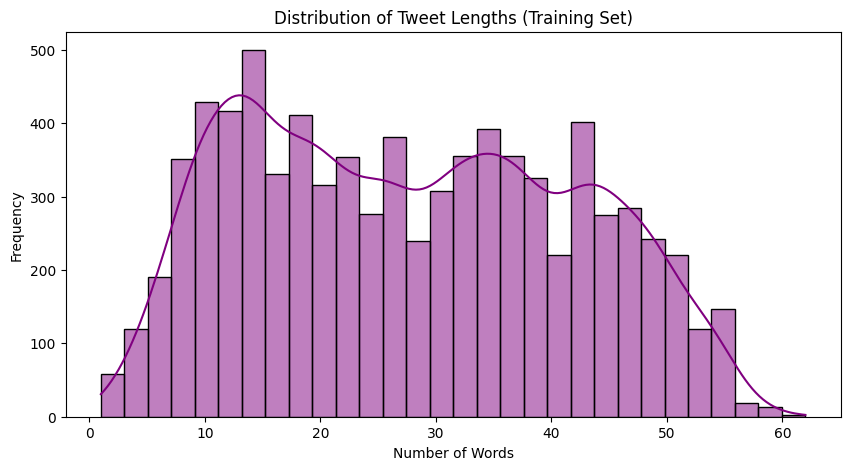

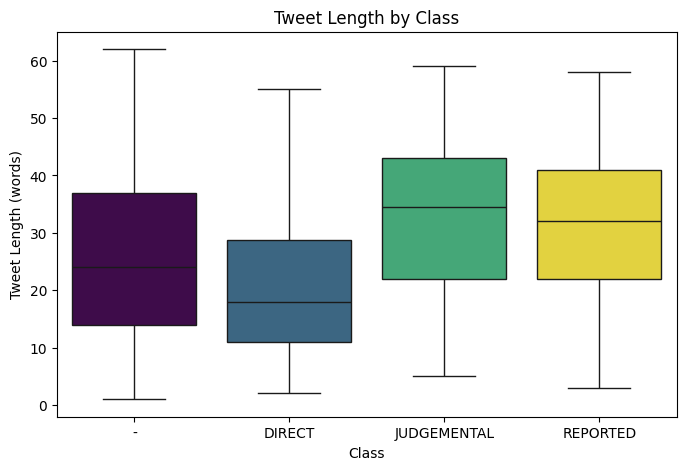

In [ ]:
train_LSTM = random_upsampler(train_LSTM)
plot_dists(train_LSTM, test_LSTM)

## Task 3: Text Encoding

### Build the vocabulary

In [ ]:
vectorizer = layers.TextVectorization()
vectorizer.adapt(train_LSTM["text"])

I0000 00:00:1767438374.070750   14669 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15480 MB memory:  -> device: 0, name: AMD Radeon RX 7800 XT, pci bus id: 0000:2d:00.0


In [ ]:
X_train_vec = vectorizer(train_LSTM["text"]).numpy()
X_val_vec = vectorizer(val_LSTM["text"]).numpy()
X_test = vectorizer(test_LSTM["text"]).numpy()
y_train = train_LSTM["label"].values
y_val = val_LSTM["label"].values
y_test = test_LSTM["label"].values

The vectorizer has its vocabulary frozen after adapt().

When we apply it to the val or test set,

any word not seen during training will automatically be replaced with the OOV token (default **UNK**, index 1).

We do not need to manually preprocess or map OOV tokens, TensorFlow will handle it internally.

### Use GloVe Embedding vectors

#### Convert GloVe format to Word2Vec format

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    glove_dst_50 = "/content/drive/MyDrive/glove.twitter.27B.50d.txt"
    glove_dst_100 = "/content/drive/MyDrive/glove.twitter.27B.100d.txt"
else:
    glove_dst_50 = "glove.twitter.27B.50d.txt"
    glove_dst_100 = "glove.twitter.27B.100d.txt"
glove_src_50 = "glove.twitter.27B.50d.txt"
glove_src_100 = "glove.twitter.27B.100d.txt"

if os.path.exists(glove_dst_50) and os.path.exists(glove_dst_100):
    print("GloVe files already exists in Drive.")
else:
    print("Downloading GloVe files...")
    !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
    !unzip -q glove.twitter.27B.zip
    print("Copying GloVe file...")
    !cp "$glove_src_50" "$glove_dst_50"
    !cp "$glove_src_100" "$glove_dst_100"
    print("Files copied successfully!")

glove_file_50 = glove_dst_50
glove_file_100 = glove_dst_100

GloVe files already exists in Drive.


In [ ]:
# Load GloVe into Gensim
twitter_glove_50 = KeyedVectors.load_word2vec_format(glove_file_50, binary=False, no_header=True)
twitter_glove_100 = KeyedVectors.load_word2vec_format(glove_file_100, binary=False, no_header=True)

print(f"Loaded Twitter GloVe with {len(twitter_glove_50.key_to_index):,} and {len(twitter_glove_100.key_to_index):,} tokens")

Loaded Twitter GloVe with 1,193,514 and 1,193,514 tokens


#### Build TensorFlow embedding matrix

In [ ]:
vocab = vectorizer.get_vocabulary()
embedding_dims = [twitter_glove_50.vector_size, twitter_glove_100.vector_size]
embedding_matrixes = [np.zeros((len(vocab), embedding_dims[0])), np.zeros((len(vocab), embedding_dims[1]))]

### OOV handling

#### Random embedding initialization for OOV words

Then we will learn them by training

In [ ]:
# Construct the embedding matrix using GloVe vectors or random initialization
# For each word in the vocabulary:
# - If the word exists in the pre-trained GloVe embeddings, use its vector.
# - Otherwise, initialize its vector with random values drawn from a uniform distribution
count_0 = 0
count_1 = 0
for i, word in enumerate(vocab):
    if i == 0: # Handling zero mask
        continue
    if word in twitter_glove_50:
        embedding_matrixes[0][i] = twitter_glove_50[word]
        embedding_matrixes[1][i] = twitter_glove_100[word]
        count_0 += 1
    else:
        embedding_matrixes[0][i] = np.random.uniform(low=-0.05, high=0.05, size=embedding_dims[0])
        embedding_matrixes[1][i] = np.random.uniform(low=-0.05, high=0.05, size=embedding_dims[1])
        count_1 += 1
print(count_0)
print(count_1)

7903
1902


## Task 4 & 5

In [ ]:
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def get_callbacks(verbose):
    return [ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.1,
      patience=2,
      min_lr=1e-5,
      verbose=verbose
  ), tf.keras.callbacks.EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=verbose
    ), TqdmCallback(verbose=0)]

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Converte y_true da (batch,) a (batch, num_classes)
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        super().update_state(y_true, y_pred, sample_weight)

def build_model(units=64, dense=64, trainable_embeddings=False, stacked=False, lr=1e-3, dropout=0.0, l2=0.0):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dims[stacked],
            weights=[embedding_matrixes[stacked]],
            mask_zero=False,
            trainable=trainable_embeddings,
            name='encoder-embedding'
        ),
        layers.Bidirectional(
            layers.LSTM(units,
                        return_sequences=stacked,
                        kernel_regularizer=regularizers.l2(l2),
                        recurrent_activation='relu',
                        unroll=True
                       )
        ),
        #layers.LayerNormalization(),
        layers.Dropout(dropout),
        layers.Bidirectional(
            layers.LSTM(units,
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(l2),
                        recurrent_activation='relu',
                        unroll=True
                        )
                       ) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        layers.Dropout(dropout) if stacked else layers.Identity(),
        layers.Dense(
            dense,
            activation = "leaky_relu",
            kernel_regularizer=regularizers.l2(l2)
        ),
        layers.Dropout(dropout),
        layers.Dense(4, activation='softmax')
    ])
    f1_metric = SparseF1Score(average='macro', name='f1_score')
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=.5),
        metrics=['accuracy', f1_metric],
        jit_compile=False
    )
    return model

def show_learning_curves(trainer_history, seed):
    epochs_loss = []
    train_loss = []
    epochs_eval = []
    val_loss = []
    val_f1 = []
    if(isinstance(trainer_history, tf.keras.callbacks.History)):
        train_loss = trainer_history.history['loss']
        val_loss = trainer_history.history['val_loss']
        val_f1 = trainer_history.history['val_f1_score']
        epochs_loss = list(range(len(train_loss)))
        epochs_eval = list(range(len(val_loss)))
    else:
        for entry in trainer_history:
            if 'loss' in entry:
                train_loss.append(entry['loss'])
                epochs_loss.append(entry['epoch'])
            if 'eval_loss' in entry:
                val_loss.append(entry['eval_loss'])
                val_f1.append(entry['eval_f1'])
                epochs_eval.append(entry['epoch'])


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(epochs_loss, train_loss, label='Training Loss', marker='o')
    ax1.plot(epochs_eval, val_loss, label='Validation Loss', marker='x')
    ax1.set_title(f'Loss Curves - Seed {seed}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # F1 Plot
    ax2.plot(epochs_eval, val_f1, label='Validation F1', color='green', marker='s')
    ax2.set_title(f'F1 Score Curve - Seed {seed}')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def report_detailed_metrics(trainer, dataset, seed):
    # Get predictions
    if(isinstance(trainer, tf.keras.Model)):
        output = trainer.predict(dataset[0])
        y_true = dataset[1]
        y_pred = np.argmax(output, axis=1)
    else:
        output = trainer.predict(dataset)
        y_true = output.label_ids
        y_pred = np.argmax(output.predictions, axis=-1)

    target_names = ["Non SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]

    # Classification Report
    print(f"\n--- Classification Report (Seed {seed}) ---")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix (Seed {seed})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc_res = acc_metric.compute(predictions=predictions, references=labels)
    # Compute all macro metrics
    f1_res = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    precision_res = precision_metric.compute(predictions=predictions, references=labels, average='macro', zero_division=0.0)
    recall_res = recall_metric.compute(predictions=predictions, references=labels, average='macro', zero_division=0.0)

    # Return with explicit keys to match TrainingArguments
    return {
        "accuracy": acc_res['accuracy'],
        "f1": f1_res['f1'],
        "precision": precision_res['precision'],
        "recall": recall_res['recall']
    }

def set_deterministic(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [ ]:
def get_process_memory():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)  # MB

def objective(trial, stacked_mode):
    hp = {
        'units': trial.suggest_categorical('units', [32, 64, 128]),
        'dense': trial.suggest_categorical('dense', [32, 64, 128]),
        'lr': trial.suggest_categorical('lr', [1e-3, 5e-4, 1e-4]),
        'l2': trial.suggest_categorical('l2', [1e-5, 1e-4, 1e-3, 1e-2]),
        'dropout': trial.suggest_float('dropout', 0.2, 0.6, step=0.1),
        'trainable_emb': trial.suggest_categorical('trainable_emb', [True, False])
    }

    print(f"\n[Trial {trial.number}] Stacked={stacked_mode} | Params: {hp}")

    # Usiamo 3 semi diversi per ogni trial per calcolare una media robusta
    seeds = [42, 888, 777]
    trial_scores = []

    try:
        for seed in seeds:
            # 1. Reset totale dell'ambiente per il nuovo seme
            tf.keras.backend.clear_session()
            set_deterministic(seed) # La tua funzione per fissare i seed (numpy, tf, random)

            # 2. Build
            model = build_model(
                units=hp['units'],
                dense=hp['dense'],
                trainable_embeddings=hp['trainable_emb'],
                stacked=stacked_mode,
                lr=hp['lr'],
                dropout=hp['dropout'],
                l2=hp['l2']
            )

            # 3. Fit (usando i tuoi split fissi)
            model.fit(
                x=X_train,
                y=y_train,
                validation_data=(X_val, y_val),
                epochs=30,
                verbose=0,
                batch_size=512,
                callbacks=get_callbacks(False) # Deve avere EarlyStopping con restore_best_weights=True
            )

            # 4. Predict e Score
            y_pred = np.argmax(model.predict(X_val, batch_size=512, verbose=0), axis=1)
            f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
            trial_scores.append(f1)

            # 5. Pulizia memoria post-seme
            del model
            gc.collect()

            # Reporting intermedio per il Pruning basato sulla media parziale
            current_avg = np.mean(trial_scores)
            trial.report(current_avg, len(trial_scores) - 1)

            # Se il primo seme collassa o va male, Optuna può tagliare il trial subito
            if trial.should_prune():
                print(f" -> Trial pruned after {len(trial_scores)} seeds")
                raise optuna.exceptions.TrialPruned()

        final_score = np.mean(trial_scores)
        print(f" -> Mean Val_F1={final_score:.4f} (from seeds {seeds}) | RAM: {get_process_memory():.1f} MB")
        return final_score

    except optuna.exceptions.TrialPruned:
        raise
    except Exception as e:
        print(f" -> ERROR Trial {trial.number}: {e}")
        return 0.0

# --- Lancio dell'ottimizzazione (identico a prima, ma con Pruner attivo) ---
pruner = optuna.pruners.MedianPruner(n_warmup_steps=0)

study_base = optuna.create_study(
    study_name="base_lstm_seed_avg_v4",
    storage="sqlite:///optimization_results.db",
    load_if_exists=True,
    direction="maximize",
    pruner=pruner
)

# Avvio ottimizzazione passandogli X e y completi
# study_base.optimize(lambda t: objective(t, X_train_all, y_train_all, False), n_trials=base_trials)
base_trials = 60 - len(study_base.trials)
#print("ue")
if base_trials > 0:
    print("\n" + "="*40)
    print(" STARTING BASE LSTM OPTIMIZATION")
    print("="*40)
    study_base.optimize(lambda t: objective(t, False), n_trials = base_trials)
else:
    print("COMPLETED BASE LSTM STUDY FOUND")

study_stacked = optuna.create_study(
    study_name="stacked_lstm_seed_avg_v4",
    storage="sqlite:///optimization_results.db",
    load_if_exists=True,
    direction="maximize",
    pruner=pruner
)
stacked_trials = 60 - len(study_stacked.trials)

if stacked_trials > 0:
    print("\n" + "="*40)
    print(" STARTING STACKED LSTM OPTIMIZATION")
    print("="*40)
    study_stacked.optimize(lambda t: objective(t, True), n_trials = stacked_trials)
else:
    print("COMPLETED STACKED LSTM STUDY FOUND")

for name, study in [("BASE", study_base), ("STACKED", study_stacked)]:
    if len(study.trials) > 0:
        print(f"\n--- Best {name} ---")
        print(f"Val_F1: {study.best_value:.4f}")
        print(f"Params: {study.best_params}")

[I 2026-01-05 11:35:38,478] Using an existing study with name 'base_lstm_seed_avg_v4' instead of creating a new one.
[I 2026-01-05 11:35:38,518] Using an existing study with name 'stacked_lstm_seed_avg_v4' instead of creating a new one.


COMPLETED BASE LSTM STUDY FOUND
COMPLETED STACKED LSTM STUDY FOUND

--- Best BASE ---
Val_F1: 0.4431
Params: {'units': 128, 'dense': 128, 'lr': 0.001, 'l2': 0.001, 'dropout': 0.30000000000000004, 'trainable_emb': True}

--- Best STACKED ---
Val_F1: 0.4307
Params: {'units': 128, 'dense': 128, 'lr': 0.001, 'l2': 0.0001, 'dropout': 0.4, 'trainable_emb': False}



Training baseline model with seed 420...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 23%|█████▌                  | 7/30 [00:40<02:13,  5.81s/epoch, accuracy=0.849, f1_score=0.848, loss=0.577, val_accuracy=0.647, val_f1_score=0.419, val_loss=1.25, learning_rate=0.001]


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 30%|██████▉                | 9/30 [00:53<02:05,  5.95s/epoch, accuracy=0.888, f1_score=0.887, loss=0.474, val_accuracy=0.647, val_f1_score=0.417, val_loss=1.35, learning_rate=0.0001]


Epoch 10: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


 37%|█████████▏               | 11/30 [01:04<01:52,  5.90s/epoch, accuracy=0.915, f1_score=0.915, loss=0.396, val_accuracy=0.653, val_f1_score=0.404, val_loss=1.4, learning_rate=1e-5]

Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.


 37%|█████████▏               | 11/30 [01:04<01:51,  5.89s/epoch, accuracy=0.915, f1_score=0.915, loss=0.396, val_accuracy=0.653, val_f1_score=0.404, val_loss=1.4, learning_rate=1e-5]


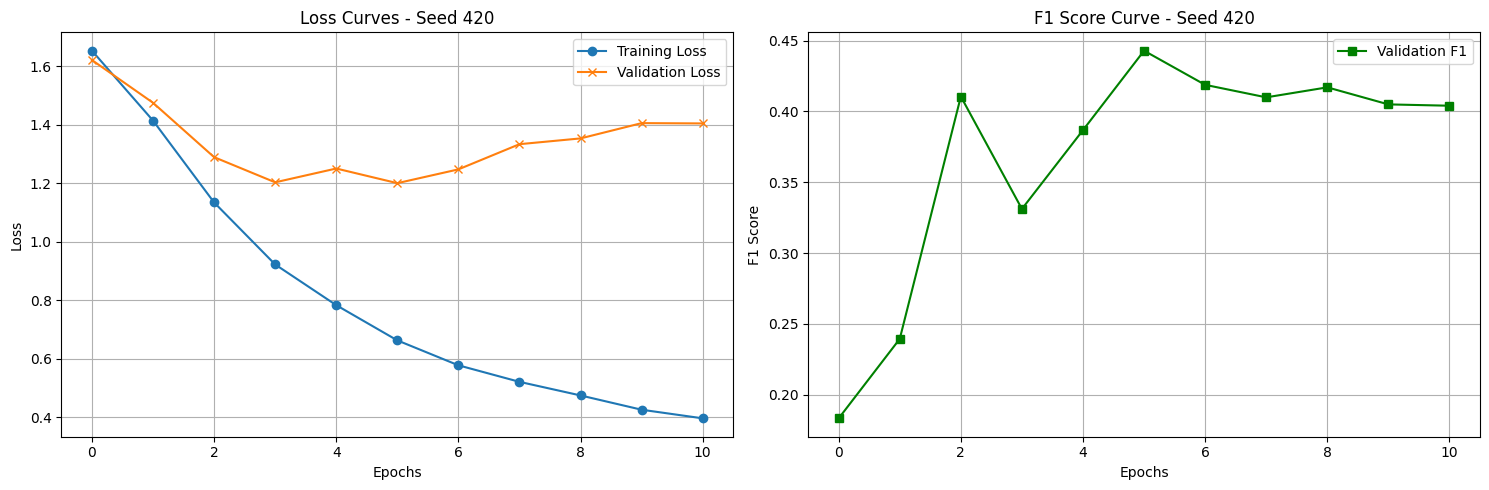

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step

--- Classification Report (Seed 420) ---
              precision    recall  f1-score   support

  Non SEXIST       0.79      0.75      0.77       179
      DIRECT       0.51      0.63      0.56        62
 JUDGEMENTAL       0.00      0.00      0.00        18
    REPORTED       0.18      0.19      0.19        21

    accuracy                           0.64       280
   macro avg       0.37      0.39      0.38       280
weighted avg       0.63      0.64      0.63       280



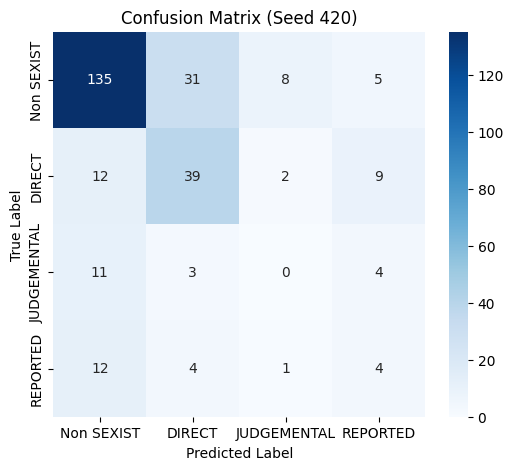

1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

Training stacked model with seed 420...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 27%|████████▊                        | 8/30 [01:29<04:06, 11.19s/epoch, accuracy=0.499, f1_score=0.494, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=0.001]


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 33%|████████████                        | 10/30 [01:51<03:42, 11.14s/epoch, accuracy=0.25, f1_score=0, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=0.0001]


Epoch 11: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


 40%|███████████████▏                      | 12/30 [02:14<03:22, 11.26s/epoch, accuracy=0.25, f1_score=0, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=1e-5]

Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.


 40%|███████████████▏                      | 12/30 [02:14<03:22, 11.22s/epoch, accuracy=0.25, f1_score=0, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=1e-5]


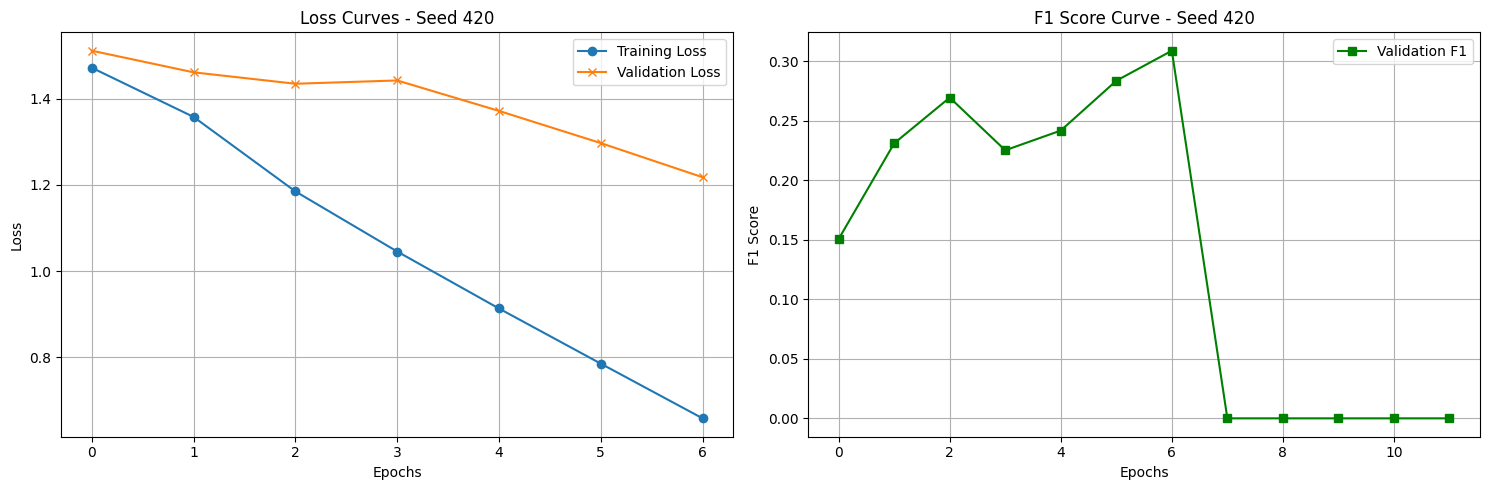

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step

--- Classification Report (Seed 420) ---
              precision    recall  f1-score   support

  Non SEXIST       0.83      0.56      0.67       179
      DIRECT       0.37      0.76      0.49        62
 JUDGEMENTAL       0.07      0.06      0.06        18
    REPORTED       0.13      0.10      0.11        21

    accuracy                           0.54       280
   macro avg       0.35      0.37      0.33       280
weighted avg       0.62      0.54      0.55       280



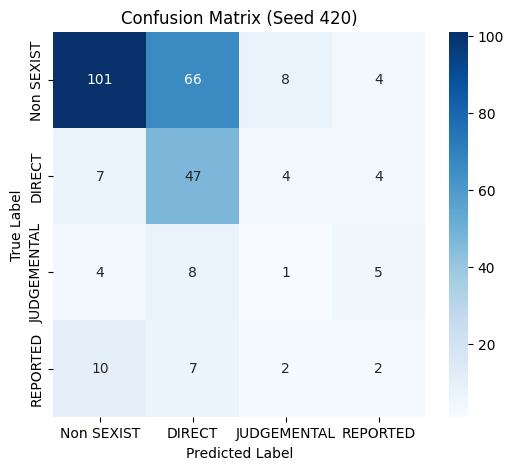

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step

Training baseline model with seed 2026...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 20%|█████▏                    | 6/30 [00:35<02:21,  5.90s/epoch, accuracy=0.82, f1_score=0.819, loss=0.642, val_accuracy=0.58, val_f1_score=0.312, val_loss=1.43, learning_rate=0.001]


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 27%|██████▉                   | 8/30 [00:47<02:09,  5.89s/epoch, accuracy=0.88, f1_score=0.88, loss=0.492, val_accuracy=0.627, val_f1_score=0.36, val_loss=1.55, learning_rate=0.0001]


Epoch 9: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


 33%|████████                | 10/30 [00:59<01:57,  5.89s/epoch, accuracy=0.903, f1_score=0.903, loss=0.426, val_accuracy=0.607, val_f1_score=0.346, val_loss=1.66, learning_rate=1e-5]

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


 33%|████████                | 10/30 [00:59<01:58,  5.91s/epoch, accuracy=0.903, f1_score=0.903, loss=0.426, val_accuracy=0.607, val_f1_score=0.346, val_loss=1.66, learning_rate=1e-5]


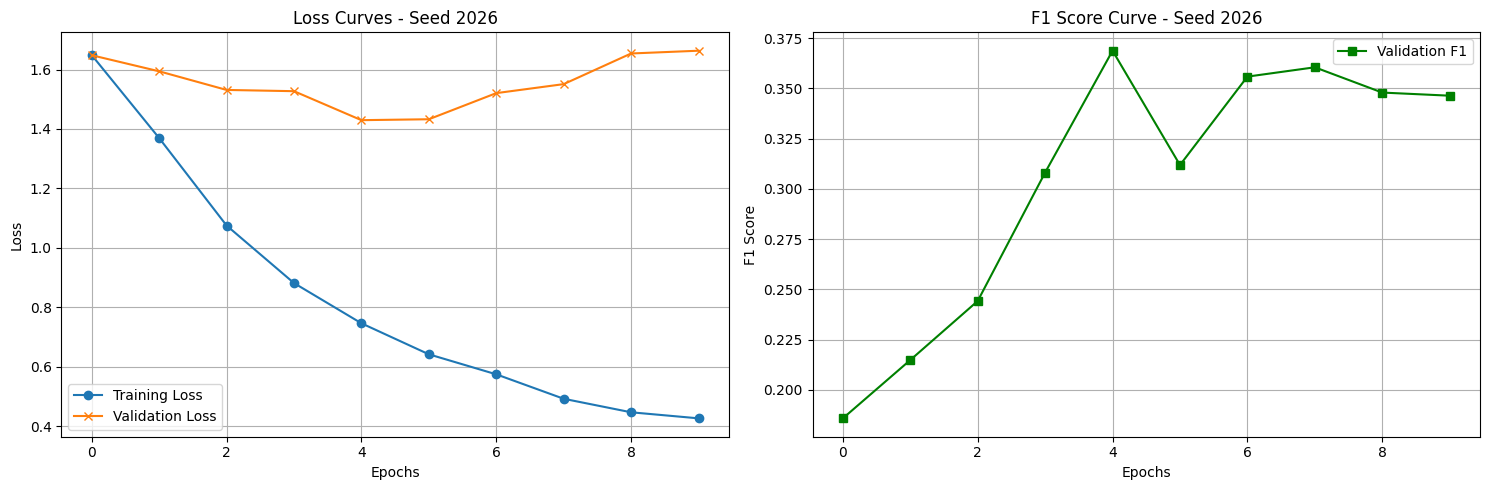

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

--- Classification Report (Seed 2026) ---
              precision    recall  f1-score   support

  Non SEXIST       0.80      0.59      0.68       179
      DIRECT       0.45      0.68      0.54        62
 JUDGEMENTAL       0.04      0.06      0.05        18
    REPORTED       0.18      0.24      0.20        21

    accuracy                           0.55       280
   macro avg       0.37      0.39      0.37       280
weighted avg       0.63      0.55      0.57       280



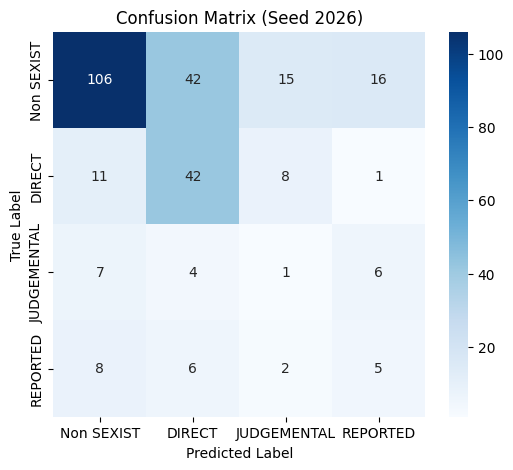

1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

Training stacked model with seed 2026...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 10%|██▋                        | 3/30 [00:34<05:06, 11.34s/epoch, accuracy=0.534, f1_score=0.525, loss=1.15, val_accuracy=0.3, val_f1_score=0.237, val_loss=1.54, learning_rate=0.001]


Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


...

 27%|███████▏                   | 8/30 [01:30<04:09, 11.34s/epoch, accuracy=0.7, f1_score=0.704, loss=0.783, val_accuracy=0.393, val_f1_score=0.288, val_loss=1.62, learning_rate=1e-5]


Epoch 9: ReduceLROnPlateau reducing learning rate to 1e-05.


 33%|████████                | 10/30 [01:53<03:44, 11.23s/epoch, accuracy=0.697, f1_score=0.701, loss=0.786, val_accuracy=0.407, val_f1_score=0.296, val_loss=1.61, learning_rate=1e-5]

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


 33%|████████                | 10/30 [01:53<03:46, 11.31s/epoch, accuracy=0.697, f1_score=0.701, loss=0.786, val_accuracy=0.407, val_f1_score=0.296, val_loss=1.61, learning_rate=1e-5]


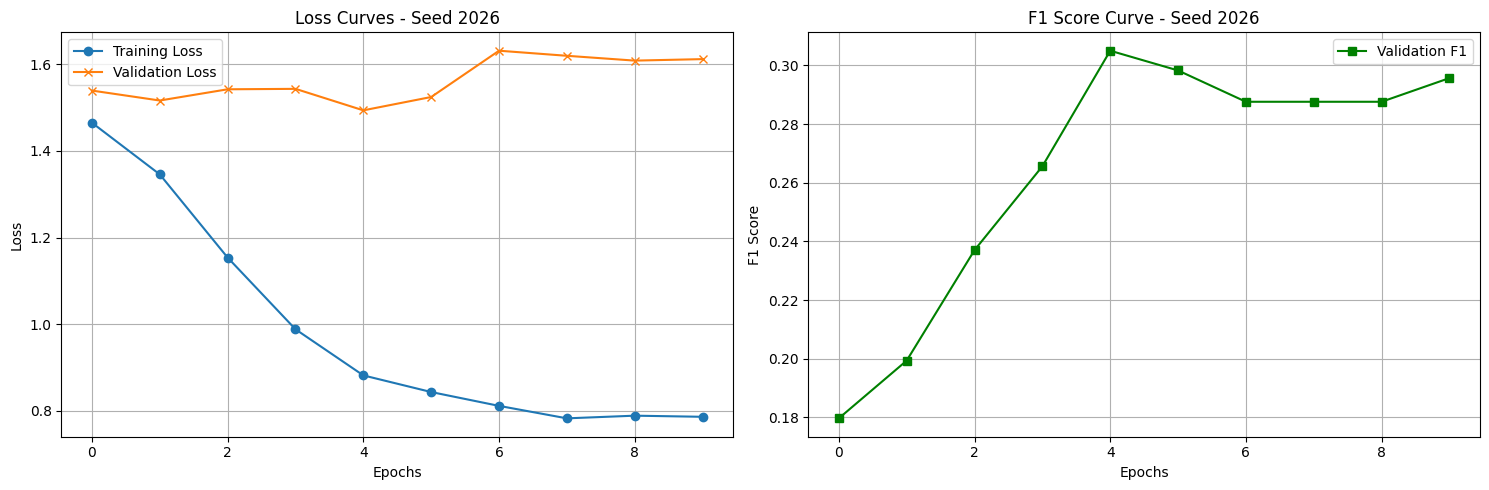

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step

--- Classification Report (Seed 2026) ---
              precision    recall  f1-score   support

  Non SEXIST       0.69      0.40      0.50       179
      DIRECT       0.31      0.63      0.42        62
 JUDGEMENTAL       0.09      0.17      0.12        18
    REPORTED       0.16      0.14      0.15        21

    accuracy                           0.41       280
   macro avg       0.31      0.33      0.30       280
weighted avg       0.53      0.41      0.43       280



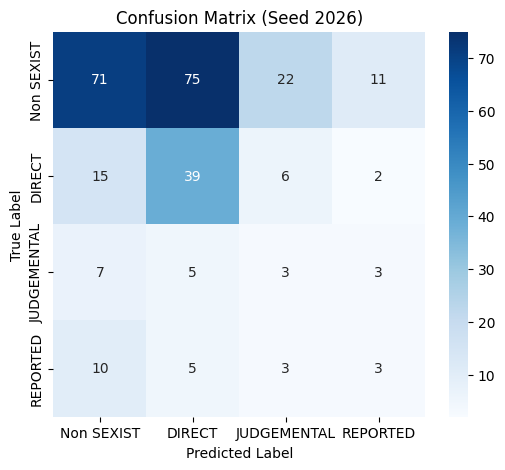

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step

Training baseline model with seed 314...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 27%|██████▍                 | 8/30 [00:47<02:12,  6.02s/epoch, accuracy=0.888, f1_score=0.887, loss=0.468, val_accuracy=0.653, val_f1_score=0.341, val_loss=1.43, learning_rate=0.001]


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 33%|███████▎              | 10/30 [00:59<01:59,  5.95s/epoch, accuracy=0.928, f1_score=0.928, loss=0.357, val_accuracy=0.707, val_f1_score=0.428, val_loss=1.45, learning_rate=0.0001]

...

 40%|██████████▊                | 12/30 [01:11<01:46,  5.90s/epoch, accuracy=0.945, f1_score=0.944, loss=0.31, val_accuracy=0.7, val_f1_score=0.417, val_loss=1.51, learning_rate=1e-5]


Epoch 13: ReduceLROnPlateau reducing learning rate to 1e-05.


 50%|████████████            | 15/30 [01:28<01:28,  5.87s/epoch, accuracy=0.946, f1_score=0.946, loss=0.303, val_accuracy=0.693, val_f1_score=0.397, val_loss=1.56, learning_rate=1e-5]

Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.


 50%|████████████            | 15/30 [01:28<01:28,  5.93s/epoch, accuracy=0.946, f1_score=0.946, loss=0.303, val_accuracy=0.693, val_f1_score=0.397, val_loss=1.56, learning_rate=1e-5]


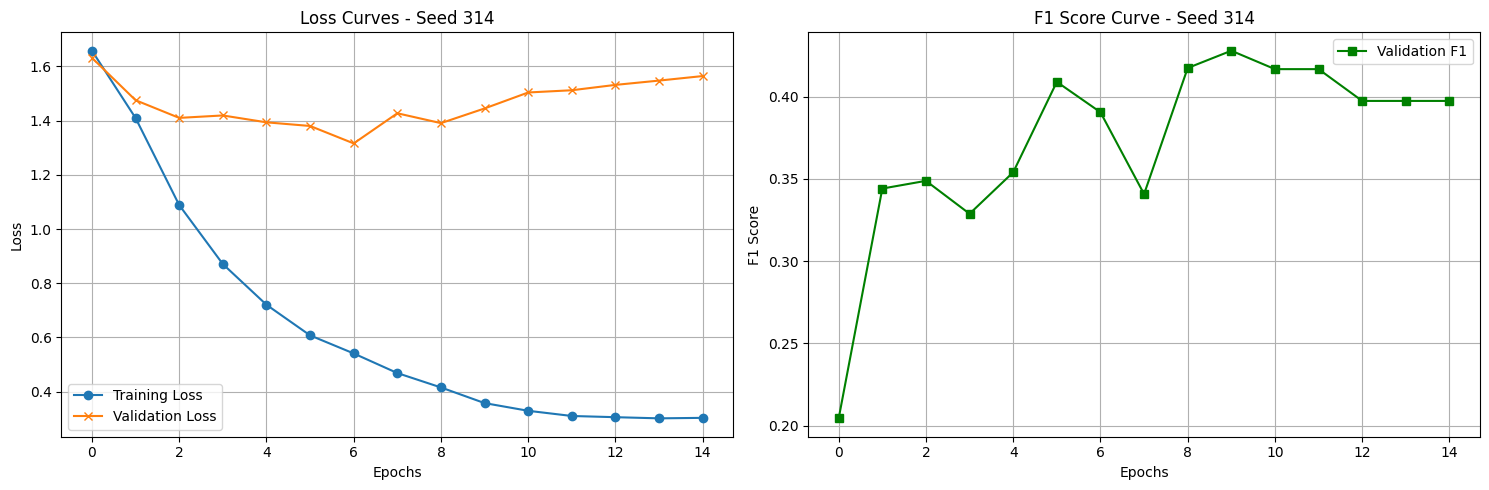

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

--- Classification Report (Seed 314) ---
              precision    recall  f1-score   support

  Non SEXIST       0.77      0.84      0.81       179
      DIRECT       0.52      0.50      0.51        62
 JUDGEMENTAL       0.11      0.06      0.07        18
    REPORTED       0.12      0.10      0.11        21

    accuracy                           0.66       280
   macro avg       0.38      0.37      0.37       280
weighted avg       0.63      0.66      0.64       280



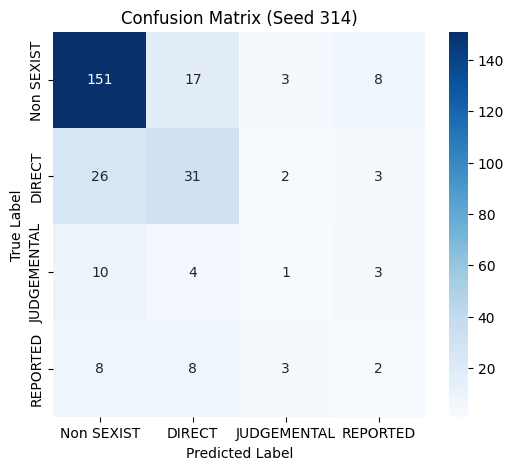

1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

Training stacked model with seed 314...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 20%|████▊                   | 6/30 [01:07<04:29, 11.22s/epoch, accuracy=0.722, f1_score=0.726, loss=0.752, val_accuracy=0.553, val_f1_score=0.323, val_loss=1.28, learning_rate=0.001]


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


...

 43%|███████████▎              | 13/30 [02:26<03:10, 11.18s/epoch, accuracy=0.848, f1_score=0.85, loss=0.458, val_accuracy=0.64, val_f1_score=0.381, val_loss=1.21, learning_rate=1e-5]


Epoch 14: ReduceLROnPlateau reducing learning rate to 1e-05.


 80%|████████████████████▊     | 24/30 [04:29<01:07, 11.17s/epoch, accuracy=0.859, f1_score=0.861, loss=0.437, val_accuracy=0.66, val_f1_score=0.39, val_loss=1.25, learning_rate=1e-5]

Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.


 80%|████████████████████▊     | 24/30 [04:29<01:07, 11.22s/epoch, accuracy=0.859, f1_score=0.861, loss=0.437, val_accuracy=0.66, val_f1_score=0.39, val_loss=1.25, learning_rate=1e-5]


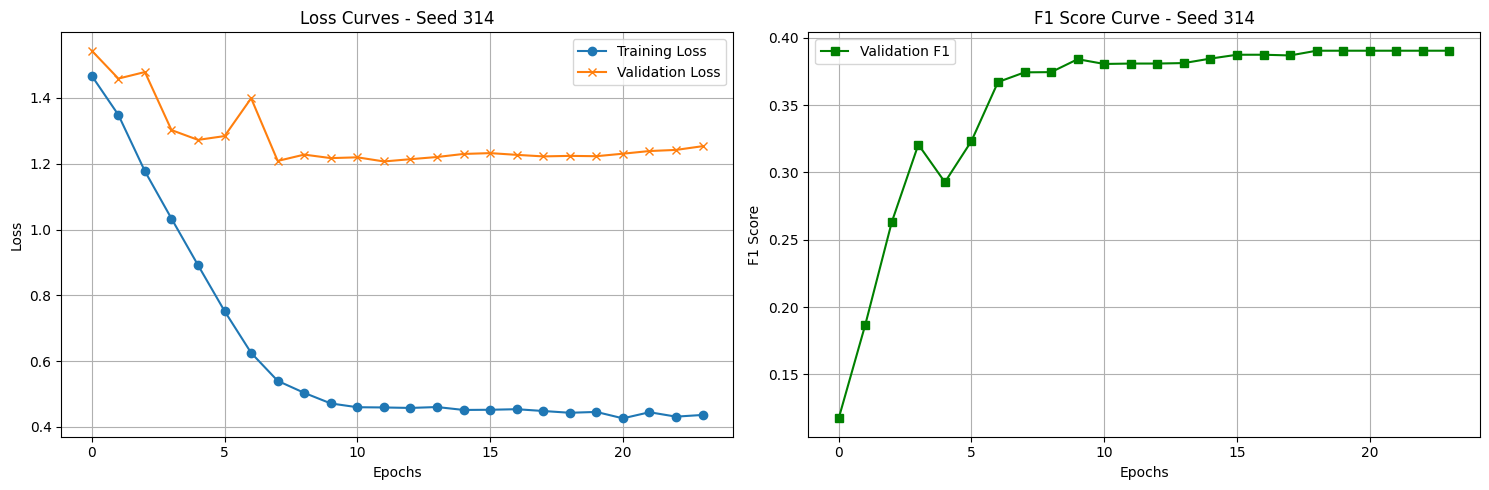

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step

--- Classification Report (Seed 314) ---
              precision    recall  f1-score   support

  Non SEXIST       0.79      0.70      0.74       179
      DIRECT       0.39      0.60      0.47        62
 JUDGEMENTAL       0.13      0.11      0.12        18
    REPORTED       0.22      0.10      0.13        21

    accuracy                           0.60       280
   macro avg       0.38      0.38      0.37       280
weighted avg       0.61      0.60      0.60       280



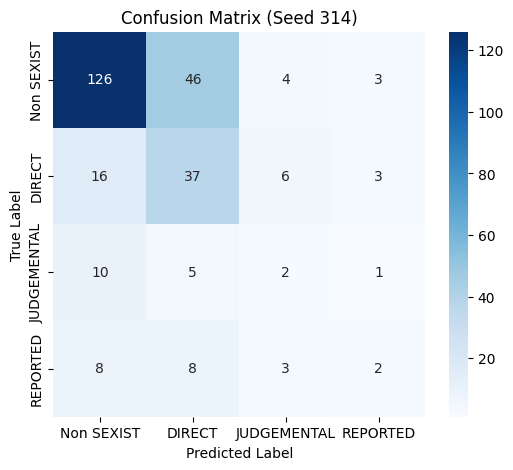

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step

Training baseline model with seed 666...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 27%|██████▉                   | 8/30 [00:47<02:09,  5.89s/epoch, accuracy=0.875, f1_score=0.875, loss=0.481, val_accuracy=0.64, val_f1_score=0.386, val_loss=1.3, learning_rate=0.001]


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 33%|████████                | 10/30 [00:59<01:57,  5.88s/epoch, accuracy=0.917, f1_score=0.917, loss=0.368, val_accuracy=0.6, val_f1_score=0.333, val_loss=1.34, learning_rate=0.0001]


Epoch 11: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


 37%|████████              | 11/30 [01:05<01:51,  5.87s/epoch, accuracy=0.928, f1_score=0.928, loss=0.333, val_accuracy=0.673, val_f1_score=0.342, val_loss=1.32, learning_rate=0.0001]

Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.


 37%|████████              | 11/30 [01:05<01:52,  5.92s/epoch, accuracy=0.928, f1_score=0.928, loss=0.333, val_accuracy=0.673, val_f1_score=0.342, val_loss=1.32, learning_rate=0.0001]


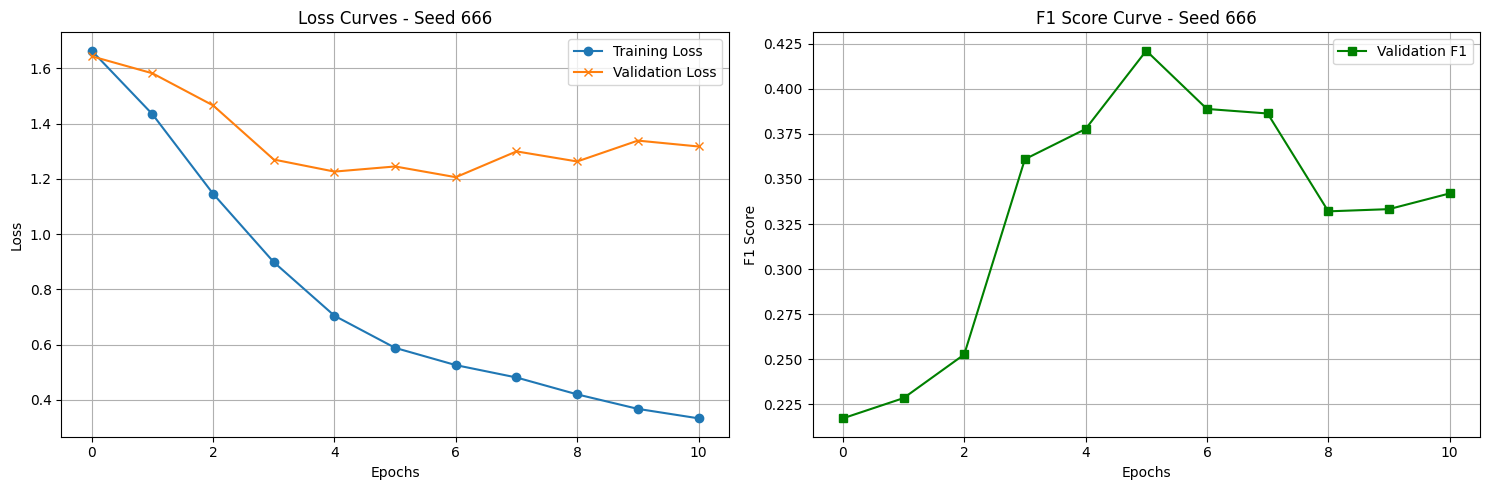

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

--- Classification Report (Seed 666) ---
              precision    recall  f1-score   support

  Non SEXIST       0.76      0.66      0.71       179
      DIRECT       0.38      0.61      0.47        62
 JUDGEMENTAL       0.18      0.11      0.14        18
    REPORTED       0.29      0.19      0.23        21

    accuracy                           0.58       280
   macro avg       0.40      0.39      0.39       280
weighted avg       0.61      0.58      0.58       280



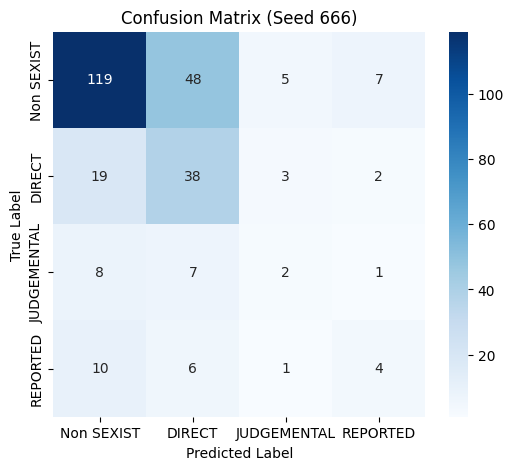

1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

Training stacked model with seed 666...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 23%|█████▊                   | 7/30 [01:18<04:17, 11.20s/epoch, accuracy=0.778, f1_score=0.78, loss=0.622, val_accuracy=0.633, val_f1_score=0.404, val_loss=1.11, learning_rate=0.001]


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


...

 37%|█████████▏               | 11/30 [02:03<03:33, 11.23s/epoch, accuracy=0.862, f1_score=0.862, loss=0.427, val_accuracy=0.607, val_f1_score=0.342, val_loss=1.2, learning_rate=1e-5]


Epoch 12: ReduceLROnPlateau reducing learning rate to 1e-05.


 40%|█████████▌              | 12/30 [02:14<03:21, 11.19s/epoch, accuracy=0.864, f1_score=0.864, loss=0.424, val_accuracy=0.613, val_f1_score=0.345, val_loss=1.21, learning_rate=1e-5]

Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.


 40%|█████████▌              | 12/30 [02:14<03:22, 11.24s/epoch, accuracy=0.864, f1_score=0.864, loss=0.424, val_accuracy=0.613, val_f1_score=0.345, val_loss=1.21, learning_rate=1e-5]


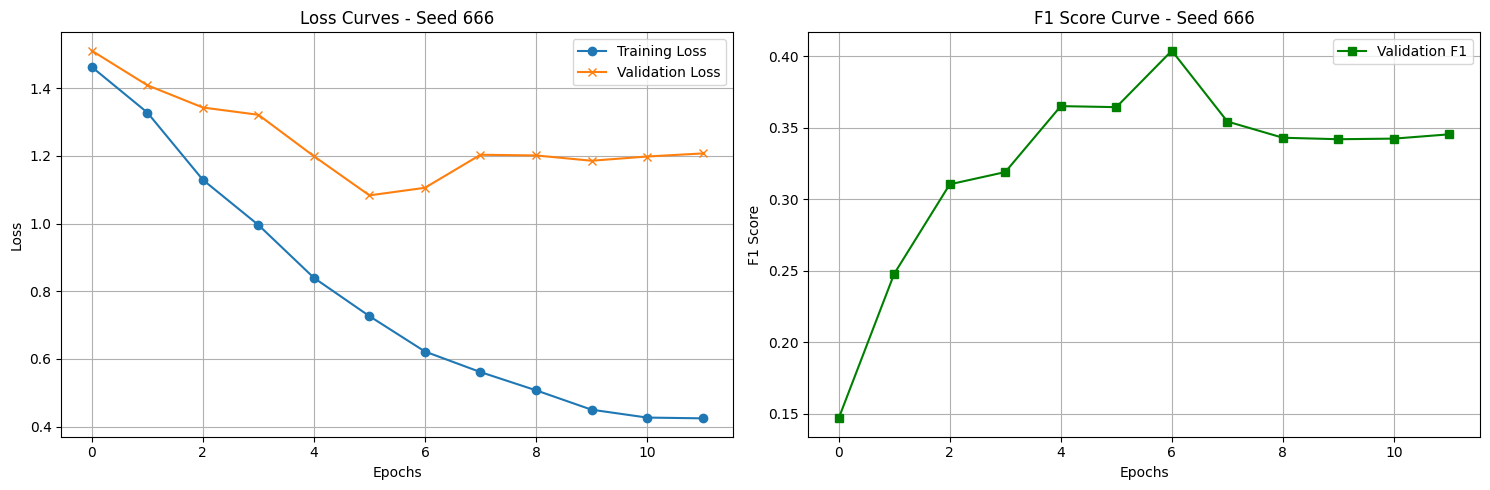

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step

--- Classification Report (Seed 666) ---
              precision    recall  f1-score   support

  Non SEXIST       0.79      0.72      0.75       179
      DIRECT       0.46      0.56      0.51        62
 JUDGEMENTAL       0.18      0.11      0.14        18
    REPORTED       0.13      0.19      0.16        21

    accuracy                           0.61       280
   macro avg       0.39      0.40      0.39       280
weighted avg       0.63      0.61      0.62       280



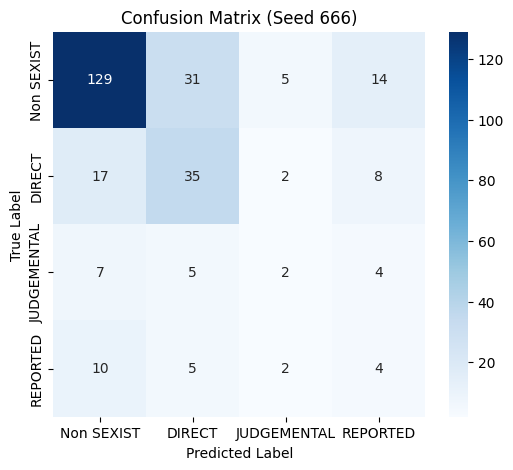

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step

Training baseline model with seed 42...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 27%|██████▍                 | 8/30 [00:47<02:12,  6.04s/epoch, accuracy=0.885, f1_score=0.885, loss=0.475, val_accuracy=0.673, val_f1_score=0.424, val_loss=1.53, learning_rate=0.001]


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 33%|███████▋               | 10/30 [00:59<01:59,  5.96s/epoch, accuracy=0.922, f1_score=0.922, loss=0.376, val_accuracy=0.74, val_f1_score=0.461, val_loss=1.28, learning_rate=0.0001]

...

 40%|██████████▍               | 12/30 [01:11<01:46,  5.91s/epoch, accuracy=0.94, f1_score=0.94, loss=0.327, val_accuracy=0.747, val_f1_score=0.478, val_loss=1.33, learning_rate=1e-5]


Epoch 13: ReduceLROnPlateau reducing learning rate to 1e-05.


 53%|████████████▊           | 16/30 [01:34<01:22,  5.90s/epoch, accuracy=0.941, f1_score=0.941, loss=0.313, val_accuracy=0.747, val_f1_score=0.478, val_loss=1.37, learning_rate=1e-5]

Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 11.


 53%|████████████▊           | 16/30 [01:34<01:22,  5.91s/epoch, accuracy=0.941, f1_score=0.941, loss=0.313, val_accuracy=0.747, val_f1_score=0.478, val_loss=1.37, learning_rate=1e-5]


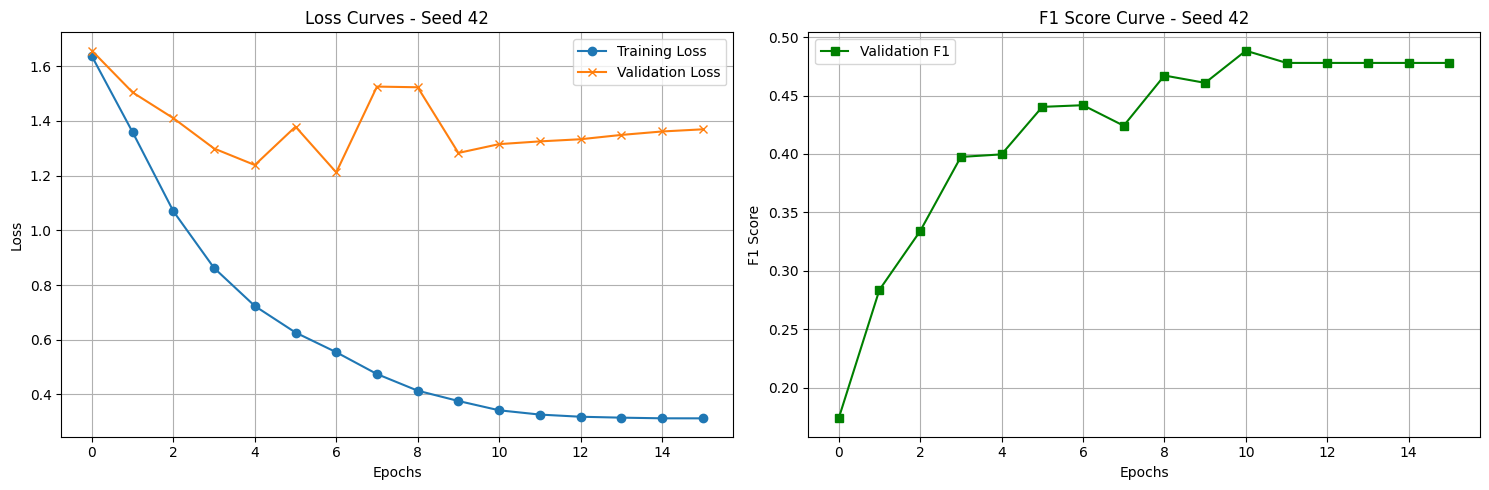

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step

--- Classification Report (Seed 42) ---
              precision    recall  f1-score   support

  Non SEXIST       0.75      0.75      0.75       179
      DIRECT       0.48      0.52      0.50        62
 JUDGEMENTAL       0.14      0.11      0.12        18
    REPORTED       0.25      0.24      0.24        21

    accuracy                           0.62       280
   macro avg       0.40      0.40      0.40       280
weighted avg       0.61      0.62      0.61       280



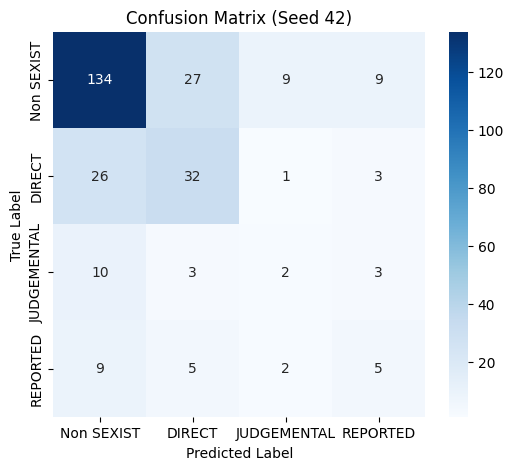

1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step

Training stacked model with seed 42...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 30%|███████▏                | 9/30 [01:41<03:59, 11.38s/epoch, accuracy=0.825, f1_score=0.826, loss=0.537, val_accuracy=0.587, val_f1_score=0.371, val_loss=1.25, learning_rate=0.001]


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


 37%|████████▍              | 11/30 [02:03<03:33, 11.25s/epoch, accuracy=0.877, f1_score=0.878, loss=0.396, val_accuracy=0.64, val_f1_score=0.386, val_loss=1.34, learning_rate=0.0001]


Epoch 12: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.


 43%|████████████████▍                     | 13/30 [02:26<03:09, 11.17s/epoch, accuracy=0.25, f1_score=0, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=1e-5]

Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


 43%|████████████████▍                     | 13/30 [02:26<03:11, 11.24s/epoch, accuracy=0.25, f1_score=0, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=1e-5]


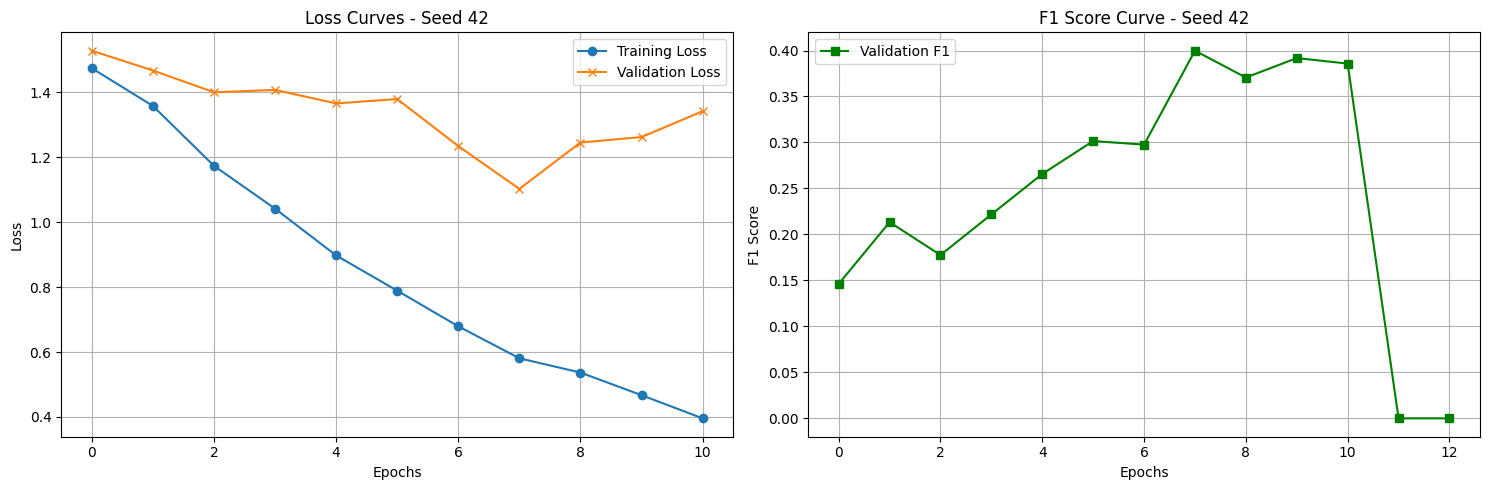

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step

--- Classification Report (Seed 42) ---
              precision    recall  f1-score   support

  Non SEXIST       0.80      0.64      0.71       179
      DIRECT       0.38      0.61      0.47        62
 JUDGEMENTAL       0.14      0.11      0.12        18
    REPORTED       0.27      0.29      0.28        21

    accuracy                           0.57       280
   macro avg       0.40      0.41      0.40       280
weighted avg       0.62      0.57      0.59       280



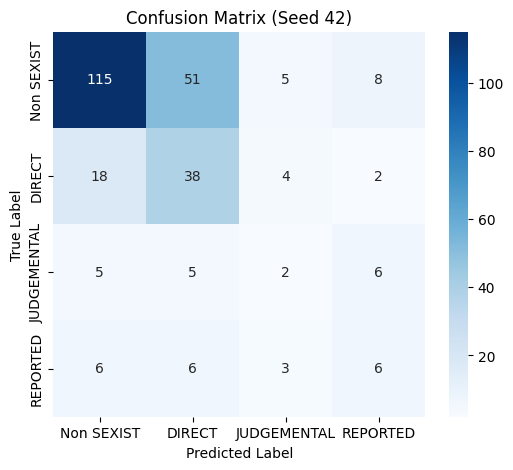

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step
Base model avg. results:
- Precision: 0.35607303845046867±0.024242039083377624
- Recall: 0.3719812235580842±0.02139381512115988
- F1: 0.35071038743853744±0.031168012927062456

Stacked model avg. results:
- Precision: 0.3961510211052922±0.008376334701405152
- Recall: 0.3969614144690735±0.01195063054543855
- F1: 0.3885299223540756±0.012380828077650584


In [ ]:
# Hyperparameters
EPOCHS = 30
SEEDS = [420, 2026, 314, 666, 42]
BATCH_SIZE = 512

classes = [0, 1, 2, 3]
history_best = []
evaluations = []
class_weights = dict(
    zip(
        classes,
        compute_class_weight(
            class_weight='balanced',
            classes=np.array(classes),
            y=y_train
        )
    )
)
for seed, model_data in list(product(SEEDS, [(False, study_base.best_params), (True, study_stacked.best_params)])):
    stacked, study = model_data
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    set_deterministic(seed)
    model = build_model(units=study['units'],
            dense=study['dense'],
            trainable_embeddings=study['trainable_emb'],
            stacked=stacked,
            lr=study["lr"],
            dropout=study['dropout'],
            l2=study['l2'])

    history = model.fit(
        x=X_train,
        y=y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(True),
        verbose=0,
        shuffle=True,
        #class_weight = class_weights
    )
    show_learning_curves(history, seed)
    #val_metrics = trainer.evaluate(val_dataset)
    report_detailed_metrics(model, (X_test, y_test), seed)
    evaluations.append(compute_metrics((model.predict(X_test), y_test)))
    if len(history_best) <= int(stacked):
        history_best.append((history, evaluations[-1]["f1"], seed))
        model.save(f"best_{"stacked" if stacked else "base"}.keras")
    if evaluations[-1]["f1"] > history_best[stacked][1]:
        history_best[stacked] = (history, evaluations[-1]["f1"], seed)
        model.save(f"best_{"stacked" if stacked else "base"}.keras")

evals_base = evaluations[:len(SEEDS)]
evals_stacked = evaluations[len(SEEDS):]
print("Base model avg. results:")
print(f"- Precision: {np.average([elem["precision"] for elem in evals_base])}±{np.std([elem["precision"] for elem in evals_base])}")
print(f"- Recall: {np.average([elem["recall"] for elem in evals_base])}±{np.std([elem["recall"] for elem in evals_base])}")
print(f"- F1: {np.average([elem["f1"] for elem in evals_base])}±{np.std([elem["f1"] for elem in evals_base])}")
print("\nStacked model avg. results:")
print(f"- Precision: {np.average([elem["precision"] for elem in evals_stacked])}±{np.std([elem["precision"] for elem in evals_stacked])}")
print(f"- Recall: {np.average([elem["recall"] for elem in evals_stacked])}±{np.std([elem["recall"] for elem in evals_stacked])}")
print(f"- F1: {np.average([elem["f1"] for elem in evals_stacked])}±{np.std([elem["f1"] for elem in evals_stacked])}")



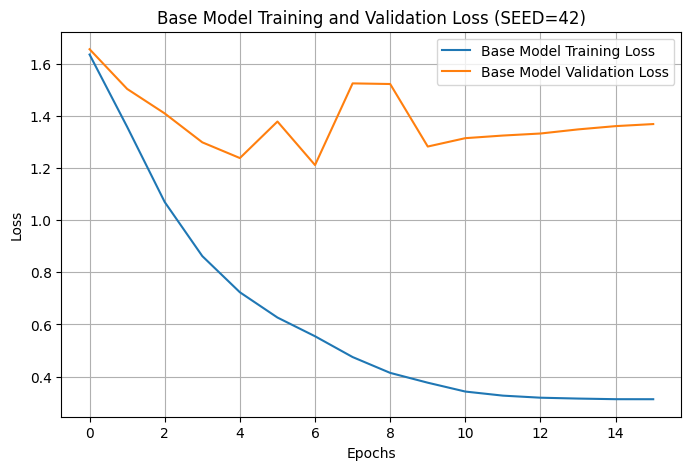

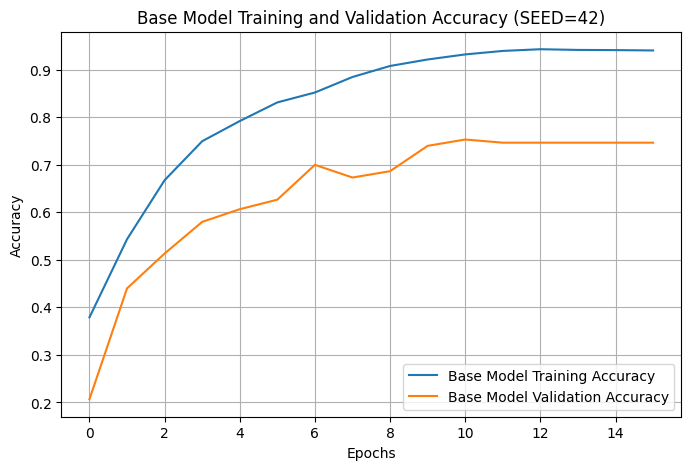

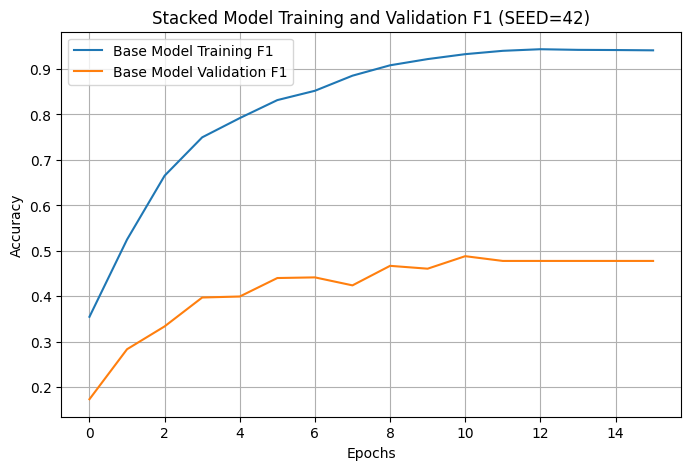

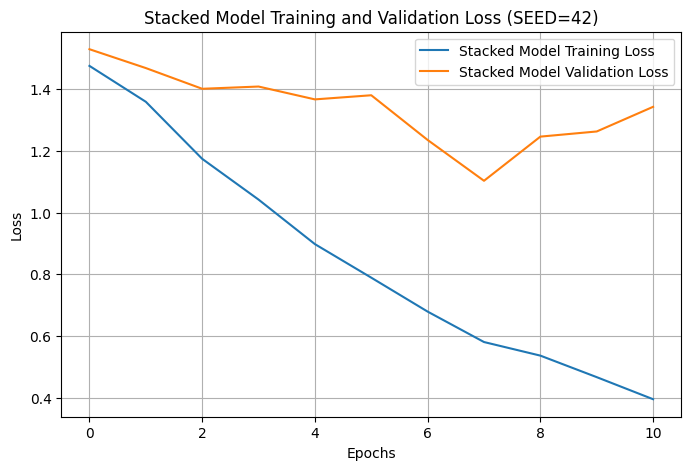

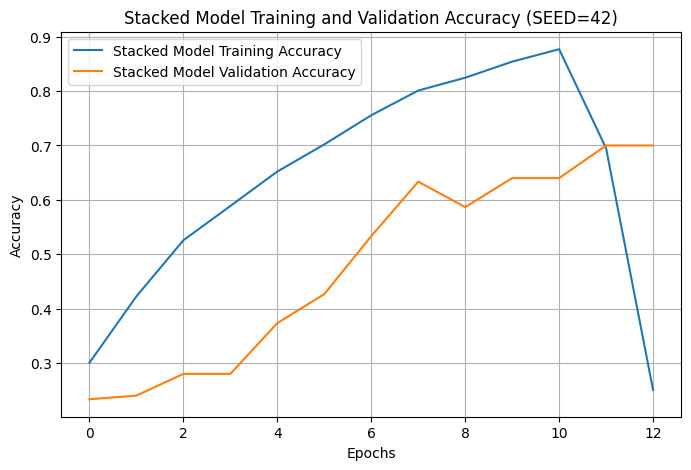

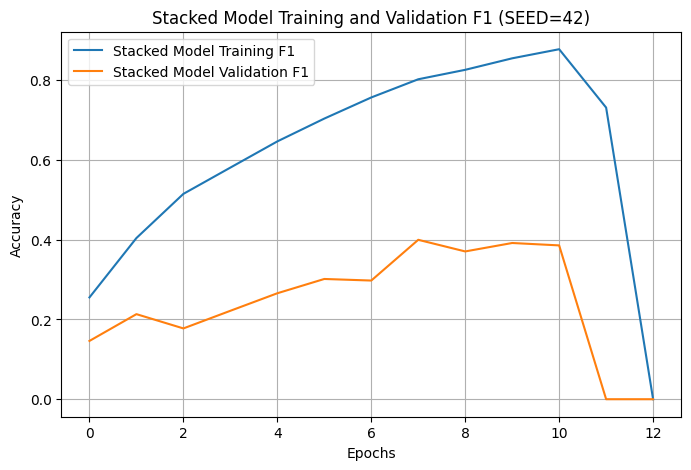

In [ ]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0][0].history['loss'], label='Base Model Training Loss')
plt.plot(history_best[0][0].history['val_loss'], label='Base Model Validation Loss')
plt.title(f'Base Model Training and Validation Loss (SEED={history_best[0][2]})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0][0].history['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0][0].history['val_accuracy'], label='Base Model Validation Accuracy')
plt.title(f'Base Model Training and Validation Accuracy (SEED={history_best[0][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[0][0].history['f1_score'], label='Base Model Training F1')
plt.plot(history_best[0][0].history['val_f1_score'], label='Base Model Validation F1')
plt.title(f'Base Model Training and Validation F1 (SEED={history_best[0][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1][0].history['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1][0].history['val_loss'], label='Stacked Model Validation Loss')
plt.title(f'Stacked Model Training and Validation Loss (SEED={history_best[1][2]})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1][0].history['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1][0].history['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title(f'Stacked Model Training and Validation Accuracy (SEED={history_best[1][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1][0].history['f1_score'], label='Stacked Model Training F1')
plt.plot(history_best[1][0].history['val_f1_score'], label='Stacked Model Validation F1')
plt.title(f'Stacked Model Training and Validation F1 (SEED={history_best[1][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Task 6: Transformers

### Create HF datasets

In [ ]:
train_ds = Dataset.from_pandas(train_ROBERTA)
valid_ds = Dataset.from_pandas(val_ROBERTA)
test_ds = Dataset.from_pandas(test_ROBERTA)

### Load tokenizer & tokenize the data

In [ ]:
model_card="cardiffnlp/twitter-roberta-base-hate"
tokenizer = AutoTokenizer.from_pretrained(model_card)

config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# Preprocess the Dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

def tokenization(train_ds, valid_ds, test_ds, tokenizer):

    # Map tokenization to the Dataset objects
    train_dataset = train_ds.map(tokenize_function, batched=True)
    val_dataset = valid_ds.map(tokenize_function, batched=True)
    test_dataset = test_ds.map(tokenize_function, batched=True)

    # Data format (will be used in Trainer)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return train_dataset, val_dataset, test_dataset, data_collator

### Helper functions to report results

In [ ]:
def show_learning_curves(trainer_history, seed):
    epochs_loss = []
    train_loss = []
    epochs_eval = []
    val_loss = []
    val_f1 = []

    for entry in trainer_history:
        if 'loss' in entry:
            train_loss.append(entry['loss'])
            epochs_loss.append(entry['epoch'])
        if 'eval_loss' in entry:
            val_loss.append(entry['eval_loss'])
            val_f1.append(entry['eval_f1'])
            epochs_eval.append(entry['epoch'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(epochs_loss, train_loss, label='Training Loss', marker='o')
    ax1.plot(epochs_eval, val_loss, label='Validation Loss', marker='x')
    ax1.set_title(f'Loss Curves - Seed {seed}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # F1 Plot
    ax2.plot(epochs_eval, val_f1, label='Validation F1', color='green', marker='s')
    ax2.set_title(f'F1 Score Curve - Seed {seed}')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def report_detailed_metrics(trainer, dataset, seed):
    # Get predictions
    output = trainer.predict(dataset)
    y_true = output.label_ids
    y_pred = np.argmax(output.predictions, axis=-1)

    target_names = ["Non SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]

    # Classification Report
    print(f"\n--- Classification Report (Seed {seed}) ---")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix (Seed {seed})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

### Setup evaluation metrics

In [ ]:
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc_res = acc_metric.compute(predictions=predictions, references=labels)
    # Compute all macro metrics
    f1_res = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    precision_res = precision_metric.compute(predictions=predictions, references=labels, average='macro', zero_division=0.0)
    recall_res = recall_metric.compute(predictions=predictions, references=labels, average='macro', zero_division=0.0)

    # Return with explicit keys to match TrainingArguments
    return {
        "accuracy": acc_res['accuracy'],
        "f1": f1_res['f1'],
        "precision": precision_res['precision'],
        "recall": recall_res['recall']
    }

### Fine-tuning

In [ ]:
def finetune_transformer(model_card, lr, epochs, train_dataset, val_dataset, test_dataset, data_collator, batch_size, weight_decay, scheduler, patience, seeds_list=[123, 12, 2028]):
    seeds = seeds_list
    results_list = []

    # Load the Model
    # Mappings as specified in Task 1 instructions
    label2id = {
        "-": 0,
        "DIRECT": 1,
        "JUDGEMENTAL": 2,
        "REPORTED": 3
    }

    id2label = {v: k for k, v in label2id.items()}

    # Trainig loop
    for seed in seeds:
        print(f"\n" + "="*60)
        print(f"RUNNING WITH SEED: {seed}")
        print("="*60)

        set_seed(seed)

        model = AutoModelForSequenceClassification.from_pretrained(model_card, num_labels=4,
                                                                   label2id=label2id,
                                                                   id2label=id2label,
                                                                   ignore_mismatched_sizes=True # Required because original model has 2 labels and, in this way,
        )                                                          # it reinitiate a new classifier head with random weights to be learned by fine-tuning

        training_args = TrainingArguments(
            learning_rate=lr,
            lr_scheduler_type=scheduler,
            weight_decay=weight_decay,                # L2 Regularization
            num_train_epochs=epochs,                  # Managed by Early Stopping
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            eval_strategy="epoch",
            logging_strategy="epoch",
            save_strategy="epoch",
            metric_for_best_model="f1",               # Optimize for Macro F1
            seed = seed,
            report_to="none"                          # Give up dear wandb :)
        )

        class MyTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
                # Explicitly pull the components from the input dictionary
                labels = inputs.get("labels")
                mask = inputs.get("attention_mask")
                input_ids = inputs.get("input_ids")

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=mask,
                    labels=labels
                )

                logits = outputs.get("logits")
                loss_fct = nn.CrossEntropyLoss()
                loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

                return (loss, outputs) if return_outputs else loss

        trainer = MyTrainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)]
        )

        trainer.train()

        # SAVE THE BEST MODEL
        # This saves the model, tokenizer, and config to the directory
        save_path = f"./model_seed__{seed}"
        trainer.save_model(save_path)
        print(f"model for seed {seed} saved to {save_path}")

        # Learning Curves, Metrics, and Confusion Matrix
        show_learning_curves(trainer.state.log_history, seed)

        # Retrieve Best Validation Metrics (from the best checkpoint loaded at the end)
        print(f"Retrieving best validation metrics for Seed {seed}...")

        val_metrics = trainer.evaluate(val_dataset)
        print(f"Best Validation F1 (Macro): {val_metrics["eval_f1"]}")

        # Detailed Performance on Test Set
        print(f"\nEvaluating Seed {seed} on Test Set...")
        report_detailed_metrics(trainer, test_dataset, seed)

        # Remove the callback so it doesn't look for eval_f1 during test evaluation
        trainer.pop_callback(EarlyStoppingCallback)

        # Evaluate on the Test Set for this specific seed
        test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")
        print(f"Test F1 (Macro): {test_metrics["test_f1"]}")

        # Store both sets of results
        results_list.append({
            "Seed": seed,
            "Valid Accuracy": val_metrics["eval_accuracy"],
            "Valid Precision": val_metrics["eval_precision"],
            "Valid Recall": val_metrics["eval_recall"],
            "Valid F1": val_metrics["eval_f1"],
            "Test Accuracy": test_metrics["test_accuracy"],
            "Test Precision": test_metrics["test_precision"],
            "Test Recall": test_metrics["test_recall"],
            "Test F1": test_metrics["test_f1"]
        })

    # Reporting Results
    # 1. Report for each seed separately first
    print("\n" + "#"*40)
    print("INDIVIDUAL SEED RESULTS")
    print("#"*40)
    results_df = pd.DataFrame(results_list)
    print(results_df.to_string(index=False))

    # 2. Report average and standard deviation
    print("\n" + "#"*40)
    print("ROBUST ESTIMATION (SUMMARY)")
    print("#"*40)

    summary_stats = results_df.drop(columns='Seed').agg(['mean', 'std']).T
    print(summary_stats)
    return summary_stats

##### Tokenization

In [ ]:
train_dataset, val_dataset, test_dataset, data_collator = tokenization(train_ds=train_ds,
                                                                       valid_ds=valid_ds, test_ds=test_ds,
                                                                       tokenizer=tokenizer)

Map:   0%|          | 0/8056 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

##### Fine-tuning


RUNNING WITH SEED: 123


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.764900,0.600091,0.766667,0.413095,0.615670,0.387112
2,0.581500,0.612201,0.760000,0.492527,0.527447,0.496661
3,0.415300,0.858269,0.800000,0.540168,0.635985,0.499612
4,0.279900,0.961207,0.780000,0.469015,0.493990,0.475647
5,0.174400,1.141963,0.786667,0.542812,0.561260,0.530280
6,0.070000,1.285700,0.773333,0.583701,0.687351,0.581936
7,0.029000,1.512371,0.793333,0.543906,0.608374,0.512733
8,0.008900,1.660340,0.780000,0.551860,0.642788,0.513613


model for seed 123 saved to ./model_seed__123


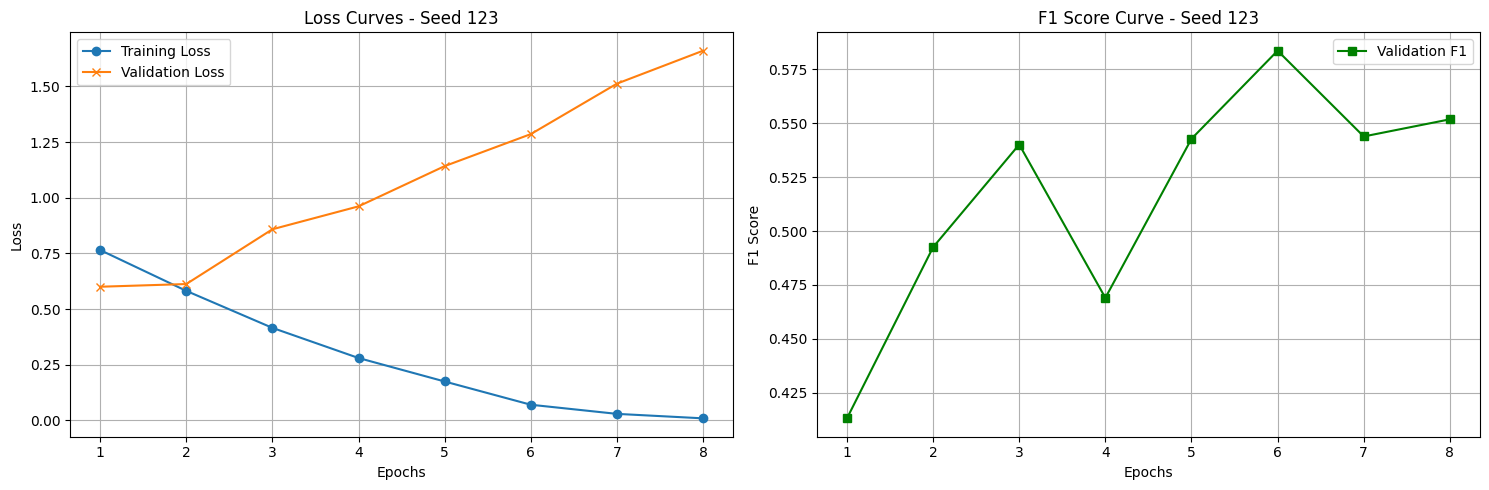

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.5518603418740218

Evaluating Seed 123 on Test Set...

--- Classification Report (Seed 123) ---
              precision    recall  f1-score   support

  Non SEXIST       0.81      0.92      0.86       179
      DIRECT       0.71      0.55      0.62        62
 JUDGEMENTAL       0.20      0.17      0.18        18
    REPORTED       0.20      0.14      0.17        21

    accuracy                           0.73       280
   macro avg       0.48      0.44      0.46       280
weighted avg       0.70      0.73      0.71       280



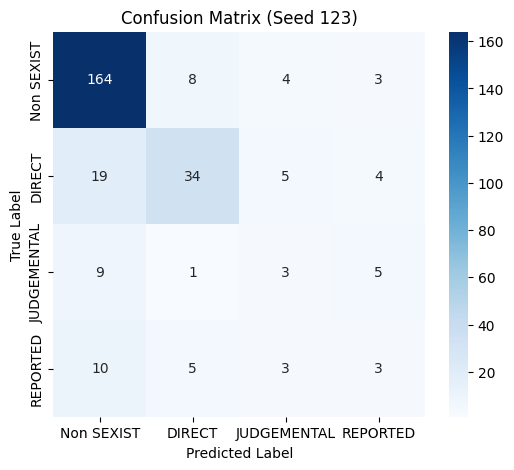

Test F1 (Macro): 0.4568897637795276

RUNNING WITH SEED: 12


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.788600,0.698518,0.740000,0.364250,0.333623,0.451035
2,0.663800,0.699559,0.780000,0.407219,0.605934,0.407376
3,0.503200,0.657688,0.786667,0.507111,0.494670,0.520471
4,0.411100,0.742344,0.820000,0.597152,0.689838,0.557686
5,0.271000,1.192426,0.773333,0.505684,0.734933,0.457350
6,0.152200,1.277864,0.793333,0.527868,0.705173,0.506936


model for seed 12 saved to ./model_seed__12


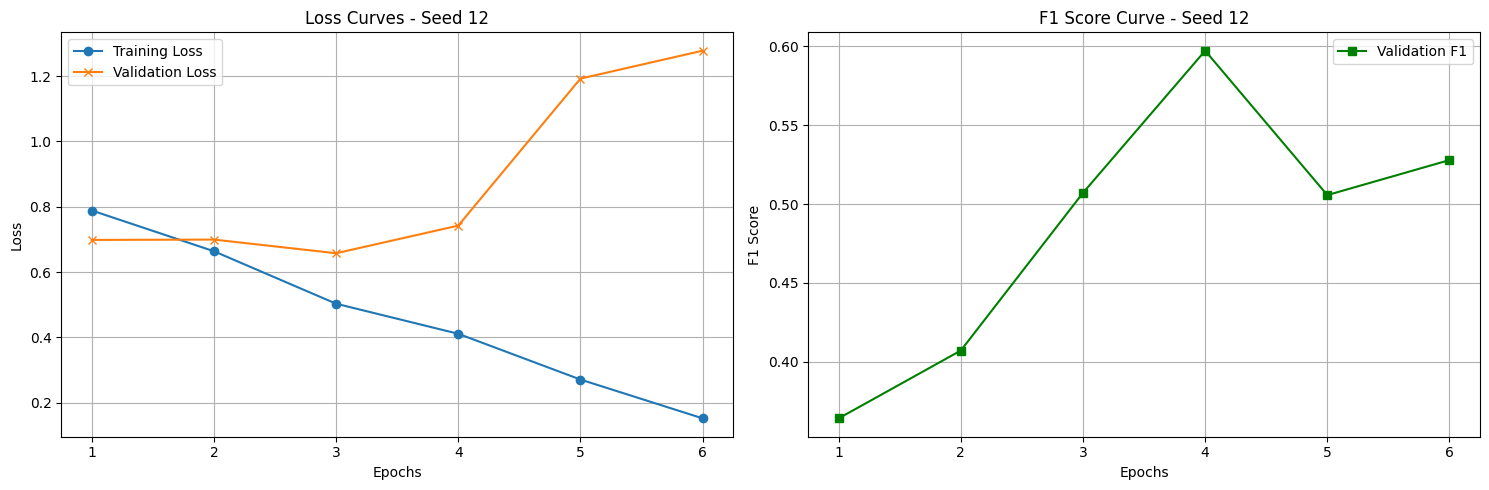

Retrieving best validation metrics for Seed 12...


Best Validation F1 (Macro): 0.5278679653679653

Evaluating Seed 12 on Test Set...

--- Classification Report (Seed 12) ---
              precision    recall  f1-score   support

  Non SEXIST       0.85      0.90      0.88       179
      DIRECT       0.72      0.61      0.66        62
 JUDGEMENTAL       0.21      0.33      0.26        18
    REPORTED       0.11      0.05      0.07        21

    accuracy                           0.74       280
   macro avg       0.47      0.47      0.46       280
weighted avg       0.72      0.74      0.73       280



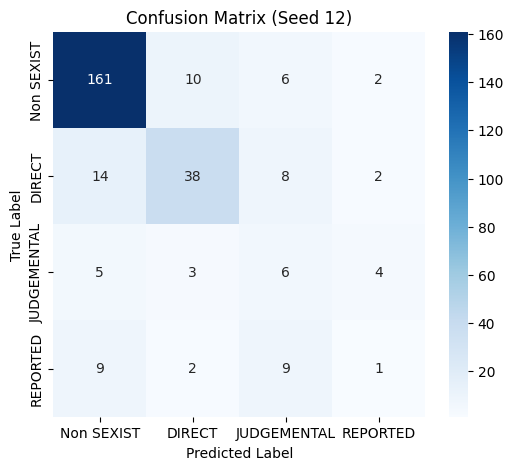

Test F1 (Macro): 0.464463845205057

RUNNING WITH SEED: 2028


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.756100,0.995806,0.720000,0.277801,0.347222,0.291097
2,0.600700,0.774861,0.780000,0.441751,0.447239,0.444281
3,0.434700,0.943461,0.813333,0.542745,0.696901,0.505745
4,0.301500,1.010887,0.746667,0.462486,0.517316,0.450673
5,0.210700,1.295243,0.786667,0.471569,0.670161,0.442340


model for seed 2028 saved to ./model_seed__2028


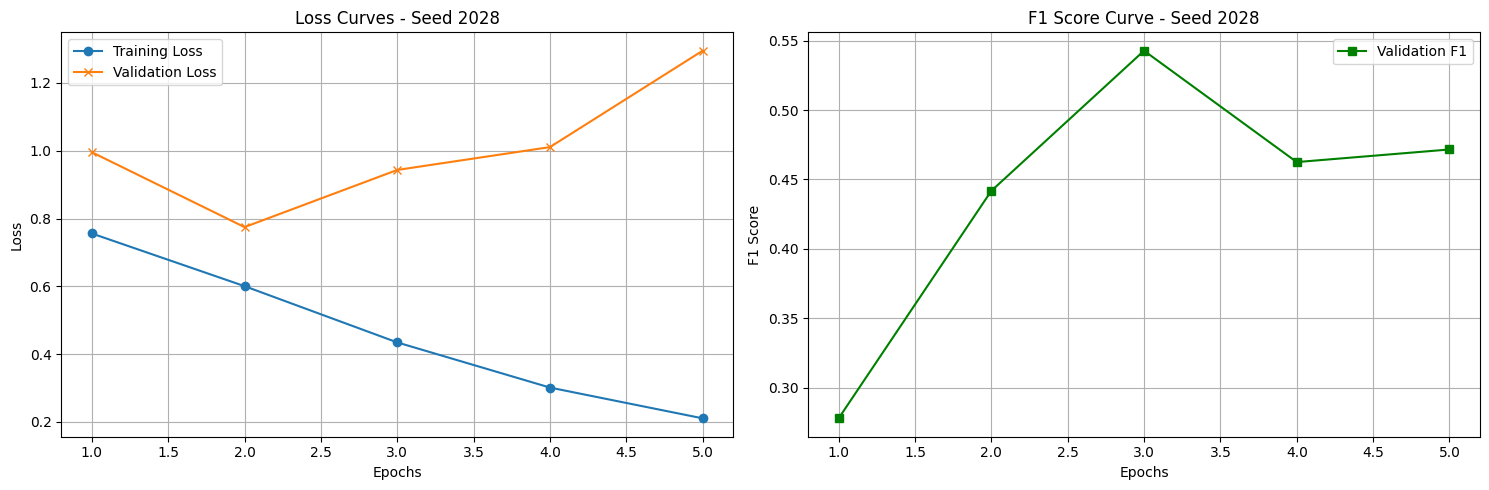

Retrieving best validation metrics for Seed 2028...


Best Validation F1 (Macro): 0.4715685705581105

Evaluating Seed 2028 on Test Set...

--- Classification Report (Seed 2028) ---
              precision    recall  f1-score   support

  Non SEXIST       0.80      0.92      0.85       179
      DIRECT       0.66      0.61      0.63        62
 JUDGEMENTAL       0.18      0.11      0.14        18
    REPORTED       0.75      0.14      0.24        21

    accuracy                           0.74       280
   macro avg       0.60      0.45      0.47       280
weighted avg       0.72      0.74      0.71       280



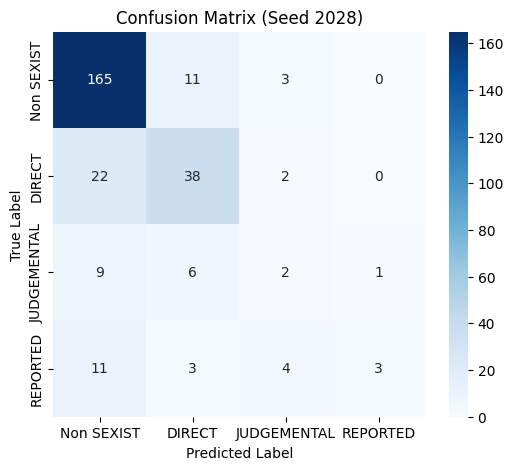

Test F1 (Macro): 0.4665466619022095

########################################
INDIVIDUAL SEED RESULTS
########################################
 Seed  Valid Accuracy  Valid Precision  Valid Recall  Valid F1  Test Accuracy  Test Precision  Test Recall  Test F1
  123        0.780000         0.642788      0.513613  0.551860       0.728571        0.480054     0.443528 0.456890
   12        0.793333         0.705173      0.506936  0.527868       0.735714        0.471710     0.473324 0.464464
 2028        0.786667         0.670161      0.442340  0.471569       0.742857        0.596023     0.447165 0.466547

########################################
ROBUST ESTIMATION (SUMMARY)
########################################
                     mean       std
Valid Accuracy   0.786667  0.006667
Valid Precision  0.672708  0.031270
Valid Recall     0.487629  0.039364
Valid F1         0.517099  0.041215
Test Accuracy    0.735714  0.007143
Test Precision   0.515929  0.069489
Test Recall      0.454672  0.0

,mean,std
Valid Accuracy,0.786667,0.006667
Valid Precision,0.672708,0.031270
Valid Recall,0.487629,0.039364
Valid F1,0.517099,0.041215
Test Accuracy,0.735714,0.007143
Test Precision,0.515929,0.069489
Test Recall,0.454672,0.016255
Test F1,0.462633,0.005082


In [ ]:
finetune_transformer(model_card="cardiffnlp/twitter-roberta-base-hate",
                     lr=5e-5, epochs=10, train_dataset=train_dataset,
                     val_dataset=val_dataset, test_dataset=test_dataset,
                     data_collator=data_collator, batch_size=8, weight_decay=0.1,
                     scheduler="cosine", patience=2, seeds_list=[123, 12, 2028])

Experiment before data augmentation, showing severe overfitting.

#### Experiment with Data augmentation

In [ ]:
# Apply random upsampling to augment minority classes, creating a balanced training set
train_ROBERTA = random_upsampler(train_ROBERTA)

# HF Datasets
train_ds = Dataset.from_pandas(train_ROBERTA)
valid_ds = Dataset.from_pandas(val_ROBERTA)
test_ds = Dataset.from_pandas(test_ROBERTA)

AUGMENTATION DONE!


##### Tokenization

In [ ]:
train_dataset, val_dataset, test_dataset, data_collator = tokenization(train_ds=train_ds,
                                                                       valid_ds=valid_ds, test_ds=test_ds,
                                                                       tokenizer=tokenizer)

Map:   0%|          | 0/8056 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

##### Fine-tuning


RUNNING WITH SEED: 123


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.057500,0.889205,0.640000,0.448197,0.447119,0.493504
2,0.925200,0.820886,0.680000,0.505315,0.483295,0.558722
3,0.874700,0.867674,0.640000,0.463524,0.476758,0.497671
4,0.839000,0.875390,0.660000,0.498514,0.496966,0.538768


model for seed 123 saved to ./model_seed__123


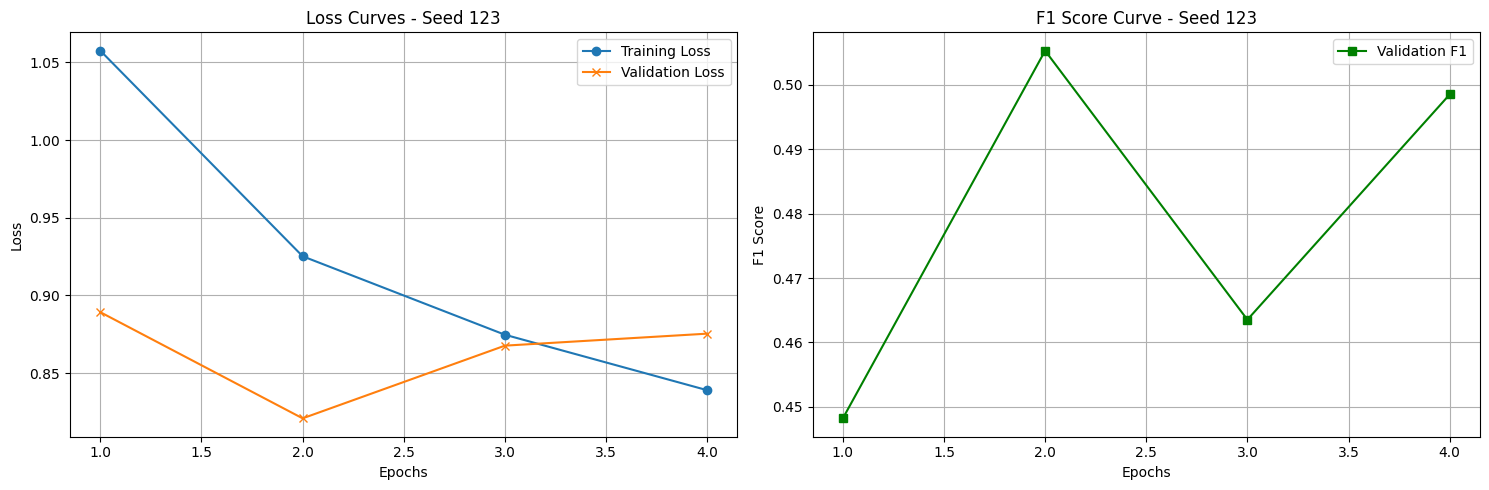

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.5053150692821249

Evaluating Seed 123 on Test Set...

--- Classification Report (Seed 123) ---
              precision    recall  f1-score   support

  Non SEXIST       0.92      0.74      0.82       179
      DIRECT       0.61      0.69      0.65        62
 JUDGEMENTAL       0.16      0.22      0.19        18
    REPORTED       0.35      0.67      0.46        21

    accuracy                           0.69       280
   macro avg       0.51      0.58      0.53       280
weighted avg       0.76      0.69      0.72       280



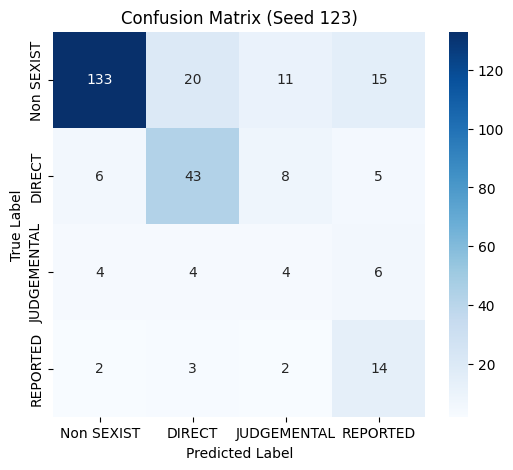

Test F1 (Macro): 0.5293914277266673

RUNNING WITH SEED: 12


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.061400,0.902545,0.640000,0.463821,0.455966,0.518970
2,0.928300,0.912504,0.653333,0.491772,0.478023,0.554840
3,0.868000,0.908542,0.653333,0.468562,0.469444,0.520885
4,0.848300,0.866141,0.666667,0.498048,0.477715,0.553960
5,0.819100,0.856978,0.700000,0.529661,0.513787,0.579995
6,0.804300,0.909263,0.660000,0.493795,0.483338,0.548732
7,0.798700,0.868426,0.686667,0.512077,0.495413,0.566744


model for seed 12 saved to ./model_seed__12


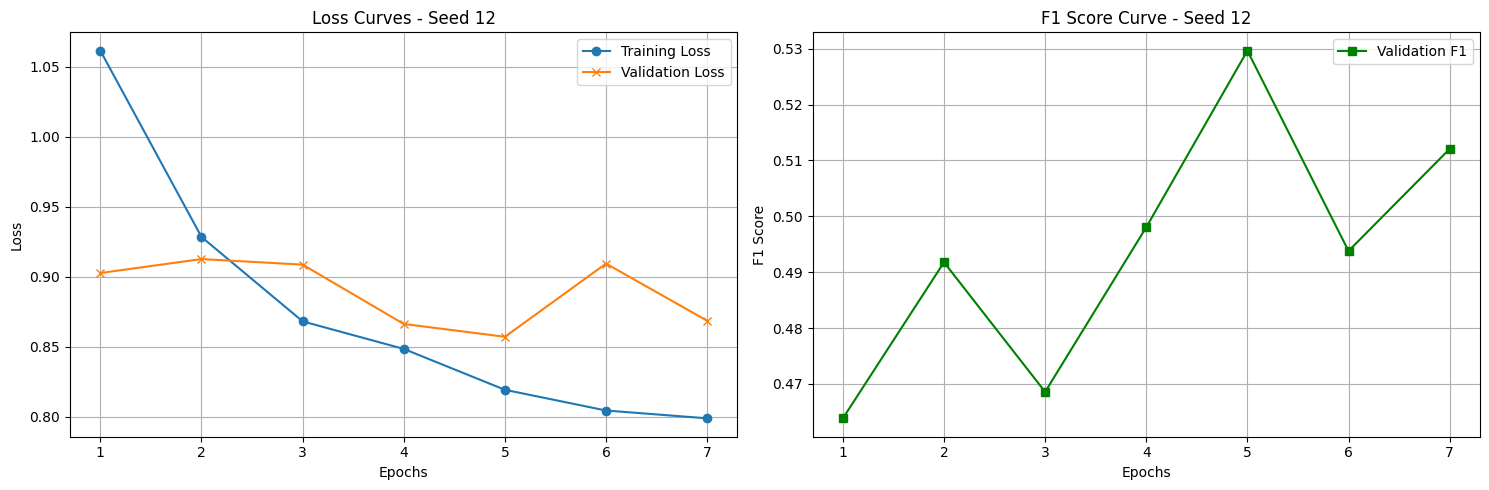

Retrieving best validation metrics for Seed 12...


Best Validation F1 (Macro): 0.5296612026647965

Evaluating Seed 12 on Test Set...

--- Classification Report (Seed 12) ---
              precision    recall  f1-score   support

  Non SEXIST       0.93      0.73      0.82       179
      DIRECT       0.67      0.65      0.66        62
 JUDGEMENTAL       0.19      0.33      0.24        18
    REPORTED       0.29      0.67      0.41        21

    accuracy                           0.68       280
   macro avg       0.52      0.59      0.53       280
weighted avg       0.78      0.68      0.71       280



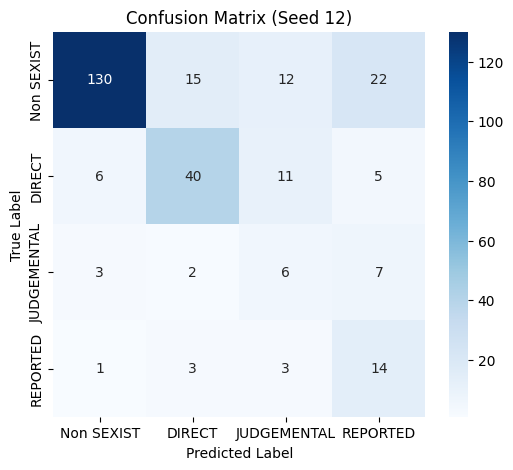

Test F1 (Macro): 0.5291454570777205

RUNNING WITH SEED: 2028


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.054100,0.867159,0.686667,0.501587,0.480696,0.552614
2,0.921800,0.934797,0.646667,0.484489,0.486028,0.535481
3,0.874700,0.857343,0.680000,0.513991,0.495059,0.572852
4,0.847500,0.886104,0.673333,0.509773,0.490246,0.570471
5,0.812200,0.866955,0.686667,0.525471,0.511161,0.575233
6,0.810200,0.899307,0.673333,0.504414,0.491972,0.561982
7,0.803400,0.875864,0.686667,0.523031,0.502888,0.583722


model for seed 2028 saved to ./model_seed__2028


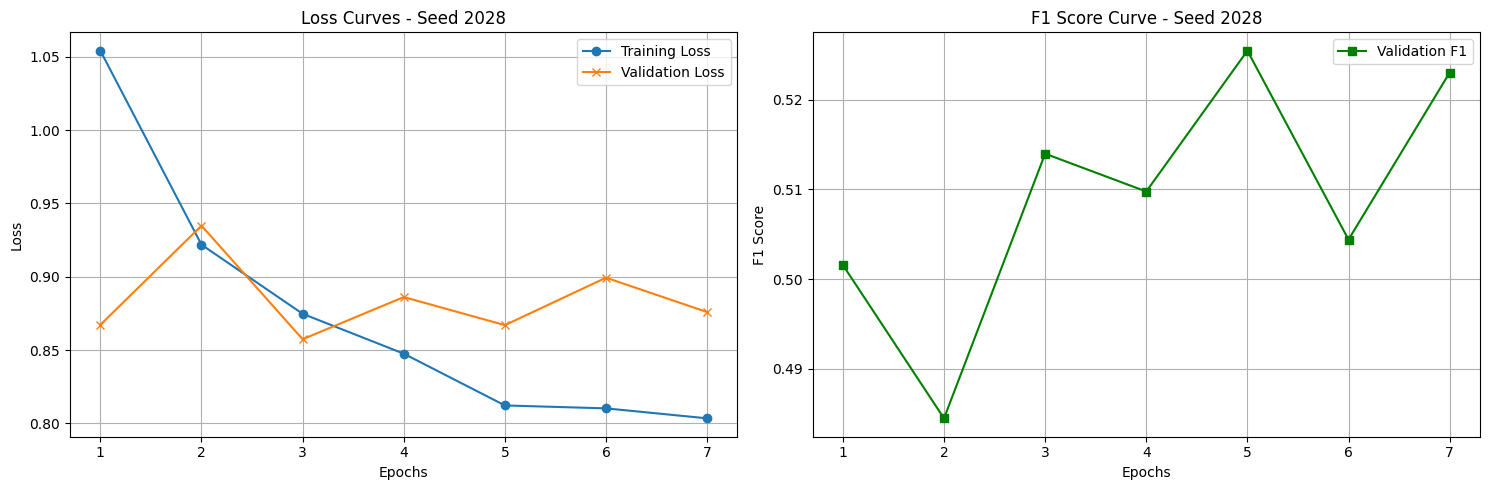

Retrieving best validation metrics for Seed 2028...


Best Validation F1 (Macro): 0.5254712996309635

Evaluating Seed 2028 on Test Set...

--- Classification Report (Seed 2028) ---
              precision    recall  f1-score   support

  Non SEXIST       0.92      0.71      0.80       179
      DIRECT       0.59      0.66      0.63        62
 JUDGEMENTAL       0.19      0.39      0.26        18
    REPORTED       0.27      0.48      0.34        21

    accuracy                           0.66       280
   macro avg       0.49      0.56      0.51       280
weighted avg       0.75      0.66      0.69       280



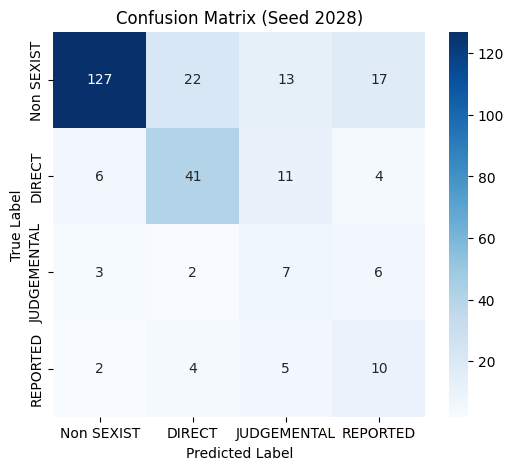

Test F1 (Macro): 0.5078257183981087

########################################
INDIVIDUAL SEED RESULTS
########################################
 Seed  Valid Accuracy  Valid Precision  Valid Recall  Valid F1  Test Accuracy  Test Precision  Test Recall  Test F1
  123        0.680000         0.483295      0.558722  0.505315       0.692857        0.510382     0.581364 0.529391
   12        0.700000         0.513787      0.579995  0.529661       0.678571        0.518601     0.592855 0.529145
 2028        0.686667         0.511161      0.575233  0.525471       0.660714        0.494802     0.558967 0.507826

########################################
ROBUST ESTIMATION (SUMMARY)
########################################
                     mean       std
Valid Accuracy   0.688889  0.010184
Valid Precision  0.502748  0.016898
Valid Recall     0.571316  0.011164
Valid F1         0.520149  0.013016
Test Accuracy    0.677381  0.016104
Test Precision   0.507928  0.012088
Test Recall      0.577728  0.0

In [ ]:
finetune_transformer(model_card="cardiffnlp/twitter-roberta-base-hate",
                     lr=5e-5, epochs=10, train_dataset=train_dataset,
                     val_dataset=val_dataset, test_dataset=test_dataset,
                     data_collator=data_collator, batch_size=8, weight_decay=0.1,
                     scheduler="cosine", patience=2, seeds_list=[123, 12, 2028])

As you can see, this experiment shows that a simple data augmentation method can reduce overfitting side effects, make the model more generalizable, and enhance overall performance.

## Task 7: Error Analysis

/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.



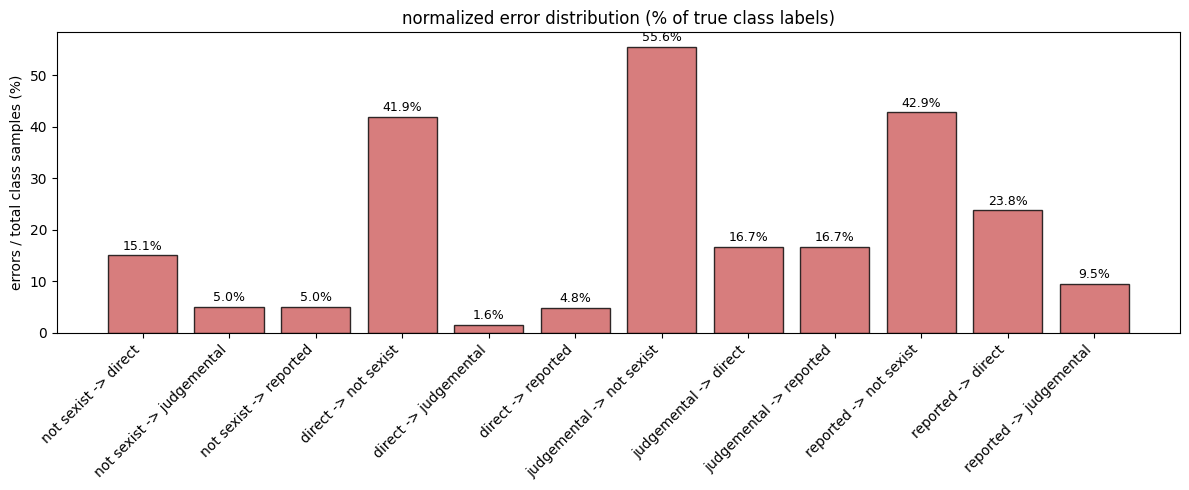

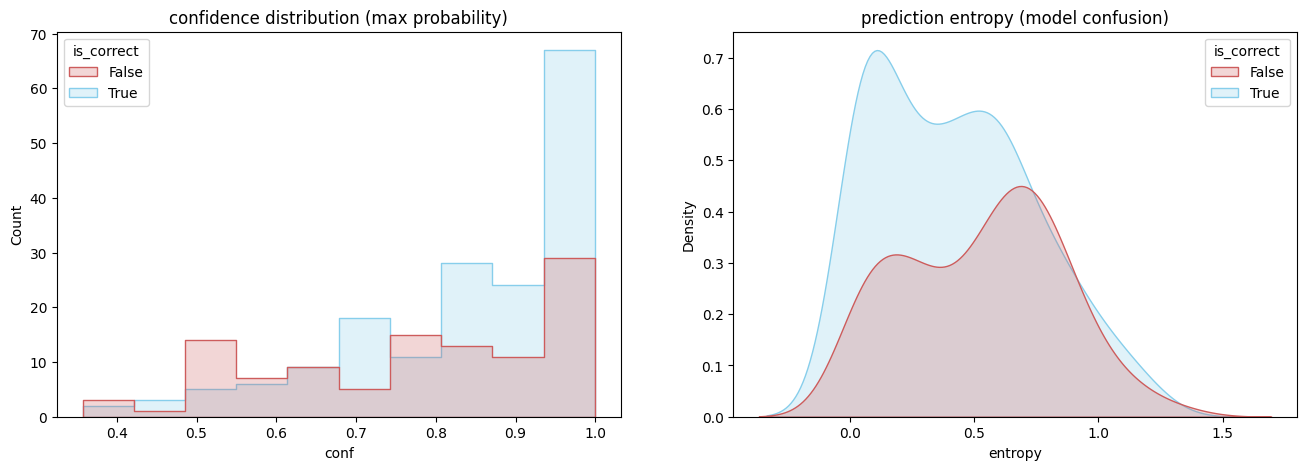

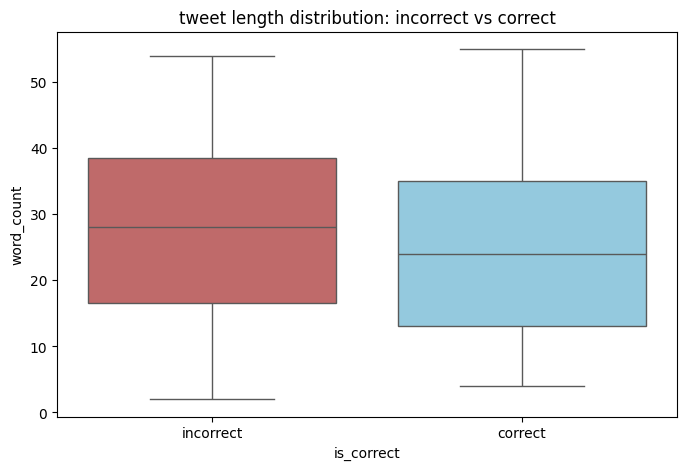

--------------------------------------------------------------------------------
linguistic patterns and high-confidence errors (top 3 pairs)
--------------------------------------------------------------------------------

judgemental -> not sexist
- class error rate: 55.6%
- mean confidence: 82.51%
- avg uppercase / excl marks: 0.0 / 0.0
- top keywords: {'have': 9, 'woman': 6, 'men': 4, 'comparison': 3, 'shouldnt': 3}
- top bigrams: ['spank woman', 'your comparison', 'romance novel']
- highest confidence error: "2 poker room the other fallacy i think you have be in term of your comparison to romance novel while you may be correct that there may be a difference in interest in your comparison there be no barrier for men to buy romance novel woman have to brace themselves for" (conf: 99.87%)

reported -> not sexist
- class error rate: 42.9%
- mean confidence: 74.73%
- avg uppercase / excl marks: 0.0 / 0.0
- top keywords: {'woman': 6, 'have': 3, 'cramp': 3, 'marginalize': 2, 'online': 2}

In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.util import ngrams
import scipy.stats

# --- 1. predictions and data assembly ---
raw_preds = model.predict(X_test, verbose=0)
y_pred = np.argmax(raw_preds, axis=1)
confidences = np.max(raw_preds, axis=1)

# main dataframe for all analyses
df_analysis = pd.DataFrame({
    'true': y_test,
    'pred': y_pred,
    'conf': confidences,
    'tweet': test_LSTM["text"].values,
    'is_correct': y_test == y_pred
})

# feature engineering
df_analysis['word_count'] = df_analysis['tweet'].apply(lambda x: len(str(x).split()))
df_analysis['upper_count'] = df_analysis['tweet'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df_analysis['excl_count'] = df_analysis['tweet'].apply(lambda x: str(x).count('!'))
# entropy measures model uncertainty (high = confused)
df_analysis['entropy'] = scipy.stats.entropy(raw_preds, axis=1)

# error-specific subset
class_totals = pd.Series(y_test).value_counts().to_dict()
df_errors = df_analysis[~df_analysis['is_correct']].copy()
error_counts = df_errors.groupby(['true', 'pred']).size().reset_index(name='count')
error_counts['percentage'] = error_counts.apply(lambda row: (row['count'] / class_totals[row['true']]) * 100, axis=1)
top_3 = error_counts.sort_values(by='percentage', ascending=False).head(3)

# --- 2. visual analysis (plots) ---

# a. normalized error barplot
plt.figure(figsize=(12, 5))
error_labels = [f"{mappings[t]} -> {mappings[p]}" for t, p in zip(error_counts['true'], error_counts['pred'])]
bars = plt.bar(error_labels, error_counts['percentage'], color='indianred', edgecolor='black', alpha=0.8)
plt.title('normalized error distribution (% of true class labels)')
plt.ylabel('errors / total class samples (%)')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# b. confidence and uncertainty distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(data=df_analysis, x='conf', hue='is_correct', element='step', palette=['indianred', 'skyblue'], ax=ax[0])
ax[0].set_title('confidence distribution (max probability)')
sns.kdeplot(data=df_analysis, x='entropy', hue='is_correct', fill=True, palette=['indianred', 'skyblue'], ax=ax[1])
ax[1].set_title('prediction entropy (model confusion)')
plt.show()

# c. stylistic metrics (length)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_analysis, x='is_correct', y='word_count', hue='is_correct', palette=['indianred', 'skyblue'], legend=False)
plt.title('tweet length distribution: incorrect vs correct')
plt.xticks([0, 1], ['incorrect', 'correct'])
plt.show()

# --- 3. linguistic and deep dive analysis ---

print("-" * 80)
print("linguistic patterns and high-confidence errors (top 3 pairs)")
print("-" * 80)

for _, row in top_3.iterrows():
    t_idx, p_idx = int(row['true']), int(row['pred'])
    subset = df_errors[(df_errors['true'] == t_idx) & (df_errors['pred'] == p_idx)]

    # pos tagging & bigrams
    words_list = []
    bigrams_list = []
    for tweet in subset['tweet']:
        tokens = [w for w in nltk.word_tokenize(str(tweet).lower()) if w.isalnum()]
        tagged = nltk.pos_tag(tokens)
        words_list.extend([w for w, tag in tagged if (tag.startswith('N') or tag.startswith('V') or tag.startswith('J')) and len(w) > 2])
        bigrams_list.extend(list(ngrams([t for t in tokens if len(t) > 2], 2)))

    print(f"\n{mappings[t_idx]} -> {mappings[p_idx]}")
    print(f"- class error rate: {row['percentage']:.1f}%")
    print(f"- mean confidence: {subset['conf'].mean():.2%}")
    print(f"- avg uppercase / excl marks: {subset['upper_count'].mean():.1f} / {subset['excl_count'].mean():.1f}")
    print(f"- top keywords: {dict(Counter(words_list).most_common(5))}")
    print(f"- top bigrams: {[' '.join(bg) for bg, f in Counter(bigrams_list).most_common(3)]}")

    # peak confidence error
    most_conf = subset.sort_values(by='conf', ascending=False).iloc[0]
    print(f"- highest confidence error: \"{most_conf['tweet']}\" (conf: {most_conf['conf']:.2%})")

print("\n" + "-" * 80)
print("boundary cases: correct predictions with lowest confidence (near-misses)")
print("-" * 80)
hard_cases = df_analysis[df_analysis['is_correct']].sort_values(by='conf').head(3)
for _, row in hard_cases.iterrows():
    print(f"- class: {mappings[row['true']]} | conf: {row['conf']:.2%}")
    print(f"  tweet: \"{row['tweet']}\"")

print("\n" + "-" * 80)
print("global summary statistics")
print("-" * 80)
print(f"- avg word count (incorrect): {df_errors['word_count'].mean():.1f}")
print(f"- avg word count (correct):   {df_analysis[df_analysis['is_correct']]['word_count'].mean():.1f}")
print(f"- critical errors (conf > 85%): {len(df_errors[df_errors['conf'] > 0.85])}")
print("-" * 80)

## Bonus

### ```bertweet-large-sexism-detector``` Model

In [ ]:
model_card = "NLP-LTU/bertweet-large-sexism-detector"
tokenizer = AutoTokenizer.from_pretrained(model_card)

train_dataset, val_dataset, test_dataset, data_collator = tokenization(train_ds=train_ds,
                                                                       valid_ds=valid_ds, test_ds=test_ds,
                                                                       tokenizer=tokenizer)

Map:   0%|          | 0/8056 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NLP-LTU/bertweet-large-sexism-detector and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 1024]) in the checkpoint and torch.Size([4, 1024]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.468600,0.894415,0.820000,0.619484,0.670797,0.585947
2,0.147800,1.259137,0.780000,0.570050,0.575200,0.574508
3,0.076600,1.494743,0.806667,0.609270,0.641372,0.585507


model for seed 123 saved to ./model_seed__123


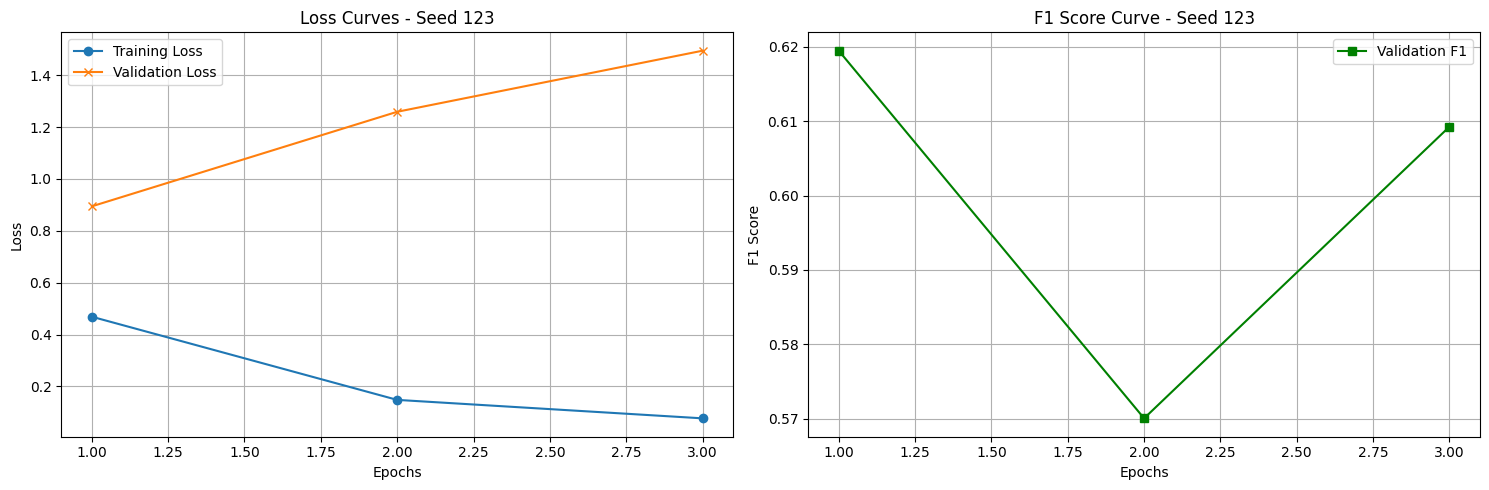

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.6194842309393394

Evaluating Seed 123 on Test Set...

--- Classification Report (Seed 123) ---
              precision    recall  f1-score   support

  Non SEXIST       0.82      0.89      0.85       179
      DIRECT       0.74      0.52      0.61        62
 JUDGEMENTAL       0.22      0.33      0.27        18
    REPORTED       0.47      0.38      0.42        21

    accuracy                           0.73       280
   macro avg       0.57      0.53      0.54       280
weighted avg       0.74      0.73      0.73       280



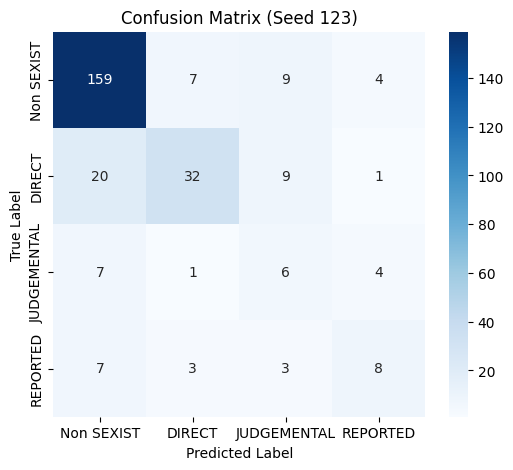

Test F1 (Macro): 0.5380204543617108

RUNNING WITH SEED: 42


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NLP-LTU/bertweet-large-sexism-detector and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 1024]) in the checkpoint and torch.Size([4, 1024]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.477200,1.061656,0.780000,0.578939,0.591747,0.570186
2,0.164600,1.226138,0.800000,0.595109,0.608841,0.583126
3,0.071300,1.407791,0.800000,0.604167,0.730974,0.574482
4,0.028300,1.790995,0.793333,0.584486,0.671257,0.549482
5,0.015600,1.934302,0.786667,0.575020,0.630091,0.542935


model for seed 42 saved to ./model_seed__42


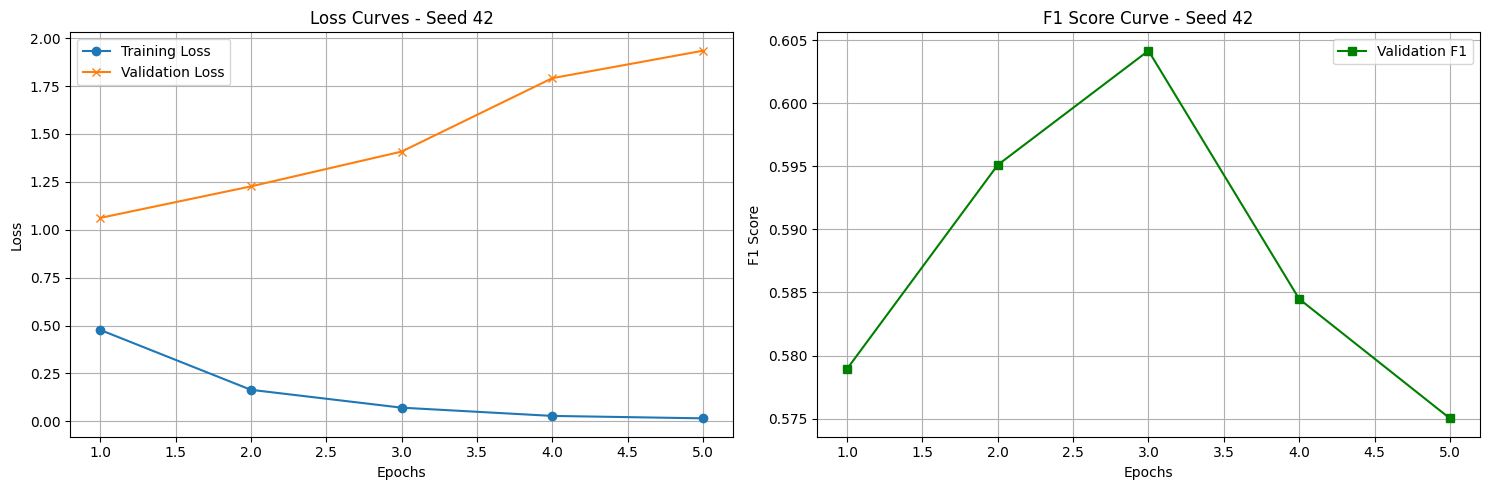

Retrieving best validation metrics for Seed 42...


Best Validation F1 (Macro): 0.6041666666666667

Evaluating Seed 42 on Test Set...

--- Classification Report (Seed 42) ---
              precision    recall  f1-score   support

  Non SEXIST       0.83      0.90      0.87       179
      DIRECT       0.72      0.55      0.62        62
 JUDGEMENTAL       0.33      0.39      0.36        18
    REPORTED       0.32      0.29      0.30        21

    accuracy                           0.74       280
   macro avg       0.55      0.53      0.54       280
weighted avg       0.74      0.74      0.74       280



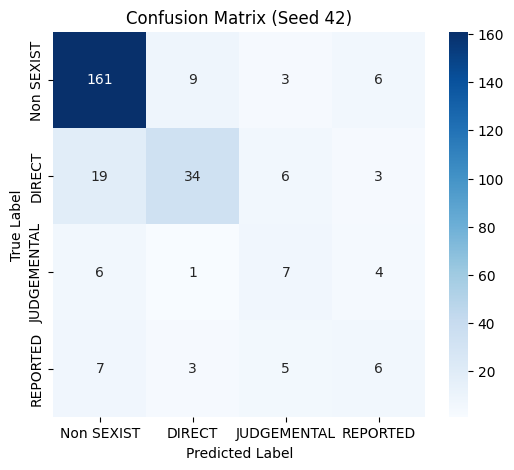

Test F1 (Macro): 0.5371047419582489

RUNNING WITH SEED: 2026


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NLP-LTU/bertweet-large-sexism-detector and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 1024]) in the checkpoint and torch.Size([4, 1024]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.483500,1.137785,0.813333,0.573645,0.595166,0.593582
2,0.167000,1.251802,0.820000,0.622555,0.680173,0.588794
3,0.084800,1.655603,0.780000,0.552447,0.593404,0.527899
4,0.041500,1.687702,0.813333,0.557026,0.695461,0.514079


model for seed 2026 saved to ./model_seed__2026


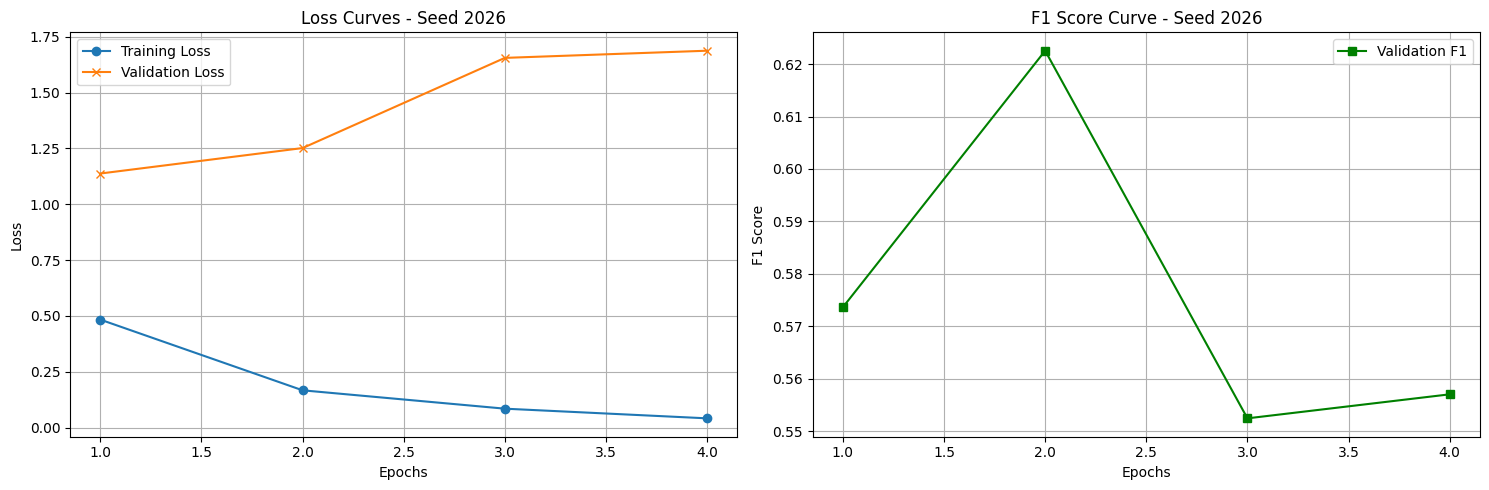

Retrieving best validation metrics for Seed 2026...


Best Validation F1 (Macro): 0.6225551750380518

Evaluating Seed 2026 on Test Set...

--- Classification Report (Seed 2026) ---
              precision    recall  f1-score   support

  Non SEXIST       0.87      0.87      0.87       179
      DIRECT       0.70      0.79      0.74        62
 JUDGEMENTAL       0.36      0.22      0.28        18
    REPORTED       0.42      0.38      0.40        21

    accuracy                           0.78       280
   macro avg       0.59      0.57      0.57       280
weighted avg       0.76      0.78      0.77       280



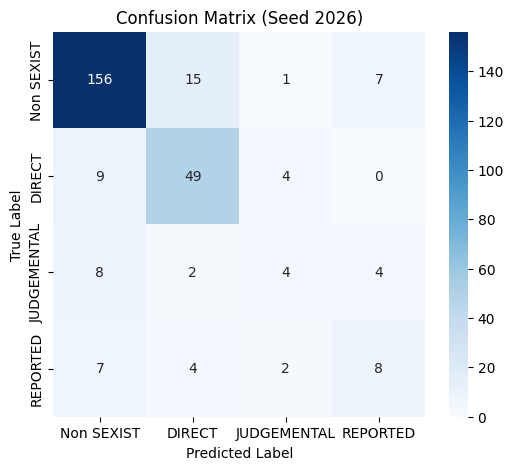

Test F1 (Macro): 0.5718417728335123

########################################
INDIVIDUAL SEED RESULTS
########################################
 Seed  Valid Accuracy  Valid Precision  Valid Recall  Valid F1  Test Accuracy  Test Precision  Test Recall  Test F1
  123            0.82         0.670797      0.585947  0.619484       0.732143        0.565208     0.529671 0.538020
   42            0.80         0.730974      0.574482  0.604167       0.742857        0.551681     0.530608 0.537105
 2026            0.82         0.680173      0.588794  0.622555       0.775000        0.587839     0.566251 0.571842

########################################
ROBUST ESTIMATION (SUMMARY)
########################################
                     mean       std
Valid Accuracy   0.813333  0.011547
Valid Precision  0.693982  0.032377
Valid Recall     0.583075  0.007576
Valid F1         0.615402  0.009851
Test Accuracy    0.750000  0.022304
Test Precision   0.568243  0.018269
Test Recall      0.542177  0.0

In [ ]:
finetune_transformer(model_card=model_card,
                     lr=1e-5 , epochs=10, train_dataset=train_dataset,
                     val_dataset=val_dataset, test_dataset=test_dataset,
                     data_collator=data_collator, batch_size=8, weight_decay=0.1,
                     scheduler="cosine", patience=2, seeds_list=[123, 42, 2026])

### Hierarchical Pipeline

In [ ]:
def prepare_hierarchichal_data(train_df, val_df, test_df, tokenizer):
    def tokenize_fn(examples):
        return tokenizer(examples["text"], padding=True, truncation=True)

    # Phase 1: Binary (0: Non-sexist, 1: Sexist)
    def to_binary(df):
        df_b = df.copy()
        df_b['label'] = df_b['label'].apply(lambda x: 0 if x == 0 else 1)
        return Dataset.from_pandas(df_b).map(tokenize_fn, batched=True)

    # Phase 2: Intent (0: Direct, 1: Judgemental, 2: Reported)
    def to_intent(df):
        df_i = df[df['label'] > 0].copy()
        df_i['label'] = df_i['label'] - 1  # Map 1,2,3 -> 0,1,2
        return Dataset.from_pandas(df_i).map(tokenize_fn, batched=True)

    # Full sets for final evaluation
    test_ds = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)
    val_ds_full = Dataset.from_pandas(val_df).map(tokenize_fn, batched=True)

    return (to_binary(train_df), to_binary(val_df)), \
           (to_intent(train_df), to_intent(val_df)), \
           test_ds, val_ds_full

In [ ]:
(bin_train, bin_val), (int_train, int_val), test_ds, val_ds_full = prepare_hierarchichal_data(train_ROBERTA, val_ROBERTA, test_ROBERTA, tokenizer)

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/8056 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/6042 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

In [ ]:
def run_training_stage(model_card, lr, epochs, train_dataset, val_dataset, num_labels, data_collator, batch_size, weight_decay, scheduler, patience, seeds_list=[123, 12, 2028]):
    seeds = seeds_list
    results_list = []

    # Update the Training Loop
    for seed in seeds:
        print(f"\n" + "="*60)
        print(f"RUNNING WITH SEED: {seed}")
        print("="*60)

        set_seed(seed)

        model = AutoModelForSequenceClassification.from_pretrained(model_card, num_labels=num_labels,
                                                                   ignore_mismatched_sizes=True)

        training_args = TrainingArguments(
            learning_rate=lr,
            lr_scheduler_type=scheduler,
            weight_decay=weight_decay,                # L2 Regularization
            num_train_epochs=epochs,                  # Managed by Early Stopping
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            eval_strategy="epoch",
            logging_strategy="epoch",
            save_strategy="epoch",
            metric_for_best_model="f1",               # Optimize for Macro F1
            load_best_model_at_end=True,
            seed = seed,
            report_to="none"                          # Give up dear wandb :)
        )

        class MyTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
                # Explicitly pull the components from the input dictionary
                labels = inputs.get("labels")
                mask = inputs.get("attention_mask")
                input_ids = inputs.get("input_ids")

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=mask,
                    labels=labels
                )

                logits = outputs.get("logits")
                loss_fct = nn.CrossEntropyLoss()
                loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

                return (loss, outputs) if return_outputs else loss

        trainer = MyTrainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)]
        )

        trainer.train()

        # SAVE THE BEST MODEL
        # This saves the model, tokenizer, and config to the directory
        save_path = f"./model_seed_{seed}_{num_labels}"
        trainer.save_model(save_path)
        print(f"model for seed {seed} saved to {save_path}")

        # Learning Curves, Metrics, and Confusion Matrix
        show_learning_curves(trainer.state.log_history, seed)

        # Retrieve Best Validation Metrics (from the best checkpoint loaded at the end)
        print(f"Retrieving best validation metrics for Seed {seed}...")

        val_metrics = trainer.evaluate(val_dataset)
        print(f"Best Validation F1 (Macro): {val_metrics["eval_f1"]}")

    return save_path

--- STARTING PHASE 1: BINARY DETECTION ---

RUNNING WITH SEED: 123


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.302800,0.625217,0.866667,0.848454,0.836997,0.866667
2,0.148000,0.790641,0.853333,0.833300,0.822408,0.850794
3,0.076200,0.806924,0.886667,0.860465,0.875000,0.849206
4,0.039500,1.074817,0.853333,0.809425,0.851593,0.787302
5,0.026600,0.905928,0.873333,0.841763,0.863017,0.826984


model for seed 123 saved to ./model_seed_123_2


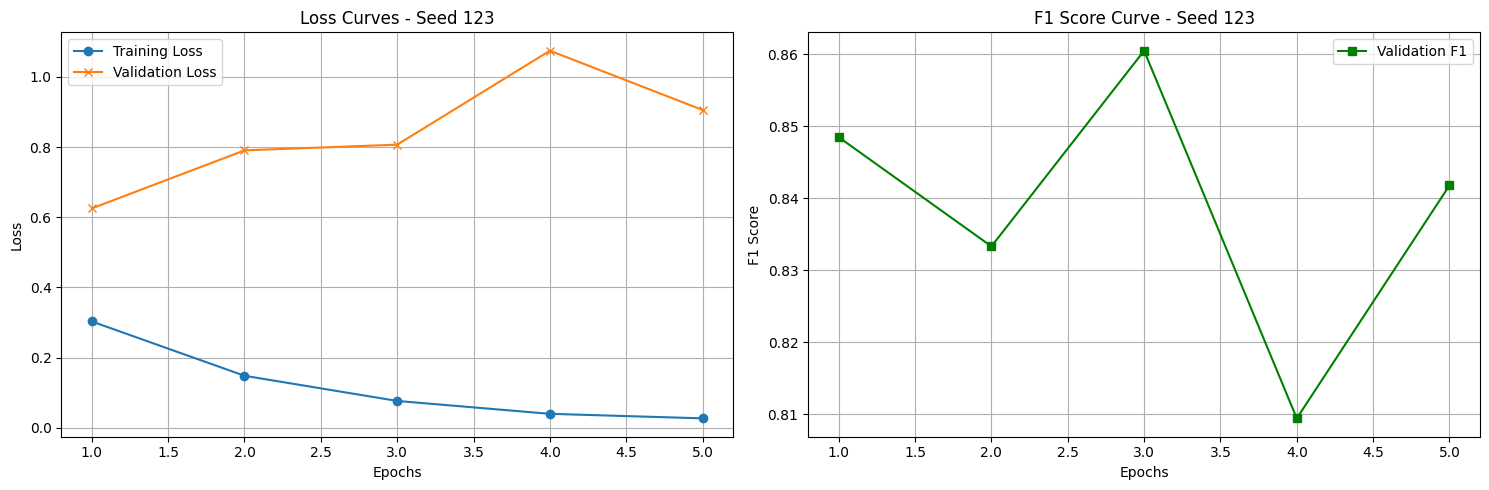

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.8604651162790697

--- STARTING PHASE 2: INTENT SPECIALIZATION ---

RUNNING WITH SEED: 123


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.298800,2.193169,0.688889,0.642012,0.639815,0.657488
2,0.030200,2.365236,0.733333,0.667236,0.711207,0.652174
3,0.010000,2.605912,0.688889,0.613191,0.640476,0.604348
4,0.003600,2.500684,0.711111,0.626206,0.650794,0.618841


model for seed 123 saved to ./model_seed_123_3


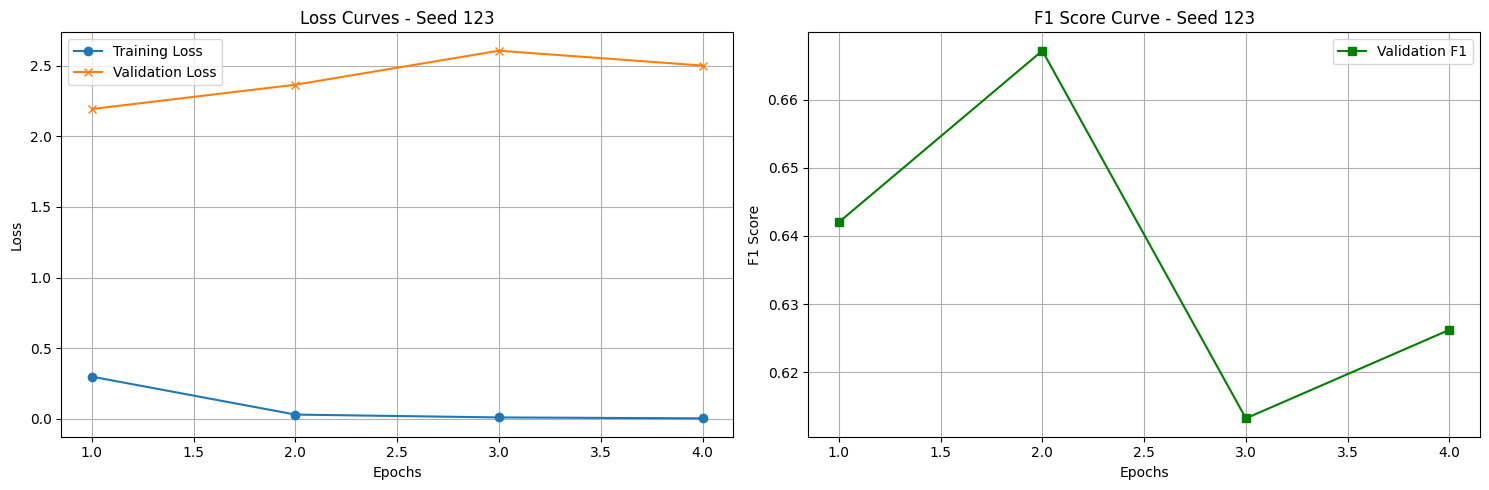

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.6672364672364672


In [ ]:
# PHASE 1: Train the Binary Gatekeeper
# Justification: High-level detection of sexist language.
print("--- STARTING PHASE 1: BINARY DETECTION ---")
best_binary_path = run_training_stage(
    model_card="cardiffnlp/twitter-roberta-base-hate",
    lr=1e-5, epochs=5, train_dataset=bin_train,
    val_dataset=bin_val, num_labels=2,
    data_collator=data_collator,
    batch_size=8, weight_decay=0.01,
    scheduler="cosine", patience=2,
    seeds_list=[123]
)

# PHASE 2: Train the Intent Specialist
print("\n--- STARTING PHASE 2: INTENT SPECIALIZATION ---")
best_intent_path = run_training_stage(
    model_card="cardiffnlp/twitter-roberta-base-hate",
    lr=5e-5, epochs=5, train_dataset=int_train,
    val_dataset=int_val, num_labels=3,
    data_collator=data_collator,
    batch_size=8, weight_decay=0.001,
    scheduler="cosine", patience=2,
    seeds_list=[123]
)

#### Load models

In [ ]:
best_binary_path = "./model_seed_123_2"
best_intent_path = "./model_seed_123_3"

In [ ]:
bin_model = AutoModelForSequenceClassification.from_pretrained(best_binary_path)
int_model = AutoModelForSequenceClassification.from_pretrained(best_intent_path)

In [ ]:
# Use standard trainer for prediction
bin_trainer = Trainer(model=bin_model)
int_trainer = Trainer(model=int_model)

#### Final evaluations on Validation set

In [ ]:
dataset = val_ds_full
predict_ds = dataset.remove_columns("label") if "label" in dataset.column_names else dataset

In [ ]:
# 3. Get Predictions using the label-less dataset
print("Running Binary Gatekeeper...")
bin_out = bin_trainer.predict(predict_ds)
bin_preds = torch.argmax(torch.from_numpy(bin_out.predictions), dim=-1)

Running Binary Gatekeeper...


In [ ]:
print("Running Intent Specialist...")
int_out = int_trainer.predict(predict_ds)
int_preds = torch.argmax(torch.from_numpy(int_out.predictions), dim=-1)

Running Intent Specialist...


In [ ]:
def final_evaluation_results(ds, bin_preds, int_preds):
    final_output = []
    for is_sexist, intent in zip(bin_preds, int_preds):
            if is_sexist == 0:
                final_output.append(0) # Label '-'
            else:
                final_output.append(intent.item() + 1) # Shift 0,1,2 -> 1,2,3

    y_pred = final_output
    y_true = ds['label'] # Original labels (0, 1, 2, 3)

    # 2. Generate the visual reports for Task 7
    target_names = ["Non SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]

    print("\n--- FINAL CLASSIFICATION REPORT ---")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # 3. Confusion Matrix for Error Analysis
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title("Hierarchical System Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return


--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Non SEXIST       0.90      0.94      0.92       105
      DIRECT       0.69      0.78      0.73        23
 JUDGEMENTAL       0.29      0.20      0.24        10
    REPORTED       0.43      0.25      0.32        12

    accuracy                           0.81       150
   macro avg       0.58      0.54      0.55       150
weighted avg       0.79      0.81      0.80       150



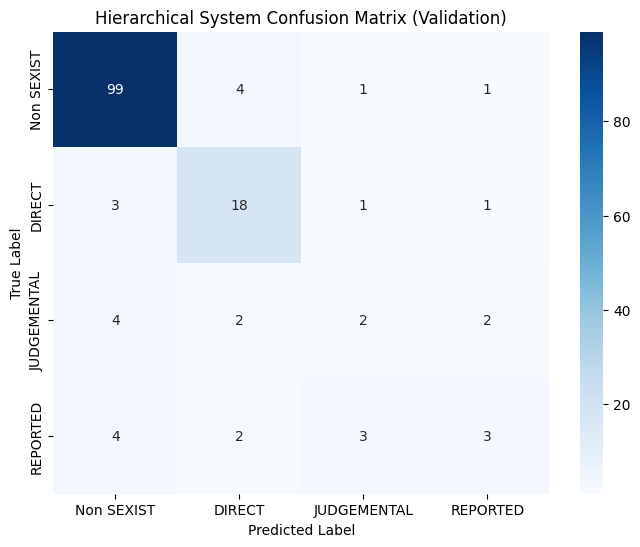

In [ ]:
final_evaluation_results(ds=val_ds_full, bin_preds=bin_preds, int_preds=bin_preds)

#### Final evaluations on test set

In [ ]:
dataset = test_ds
# remove labels to predict them by loaded models
predict_ds = dataset.remove_columns("label") if "label" in dataset.column_names else dataset

In [ ]:
print("Running Binary Gatekeeper...")
bin_out = bin_trainer.predict(predict_ds)
bin_preds = torch.argmax(torch.from_numpy(bin_out.predictions), dim=-1)

Running Binary Gatekeeper...


In [ ]:
print("Running Intent Specialist...")
int_out = int_trainer.predict(predict_ds)
int_preds = torch.argmax(torch.from_numpy(int_out.predictions), dim=-1)

Running Intent Specialist...



--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Non SEXIST       0.85      0.87      0.86       179
      DIRECT       0.65      0.63      0.64        62
 JUDGEMENTAL       0.43      0.33      0.38        18
    REPORTED       0.30      0.33      0.32        21

    accuracy                           0.74       280
   macro avg       0.56      0.54      0.55       280
weighted avg       0.74      0.74      0.74       280



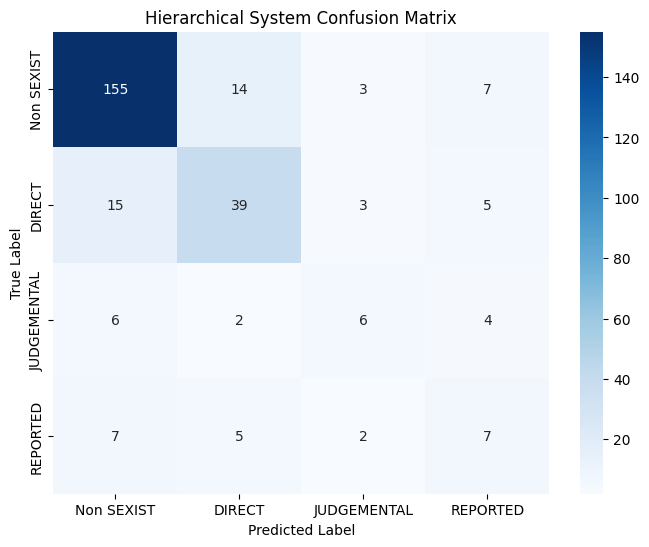

In [ ]:
final_evaluation_results(ds=test_ds, bin_preds=bin_preds, int_preds=bin_preds)